# EDA, Data Preprocessing e PCA — Employee Attrition
**Business Intelligence per Big Data — Politecnico di Torino, AA 2025-2026**

Questo notebook copre la fase di **esplorazione, pulizia e riduzione dimensionale** del dataset Attrition prima della classificazione.
L'obiettivo è produrre un dataset **pulito e ottimale** da passare agli algoritmi di classificazione.

Pipeline:
1. Import librerie
2. Caricamento dati
3. Panoramica del dataset e classificazione degli attributi
4. Analisi Esplorativa (EDA)
5. Data Preprocessing
6. PCA

## 1. Import Librerie

In [20]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.decomposition import PCA
from mpl_toolkits.mplot3d import Axes3D

import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.figsize'] = (10, 5)
sns.set_style('whitegrid')

## 2. Caricamento dei Dati

Il dataset è diviso in train (600 righe) e test (150 righe). Il test set non viene mai usato nella fase di analisi e preprocessing — le trasformazioni vengono *fittate* sempre sul train e poi applicate al test.

In [21]:
train = pd.read_excel('materiale_attrition/attrition_train.xlsx')
test  = pd.read_excel('materiale_attrition/attrition_test.xlsx')

print(f'Train: {train.shape[0]} righe, {train.shape[1]} colonne')
print(f'Test:  {test.shape[0]} righe,  {test.shape[1]} colonne')
train.head()

Train: 600 righe, 33 colonne
Test:  150 righe,  33 colonne


,Age,Gender,MaritalStatus,DistanceFromHome,Education,EducationField,Department,JobRole,JobLevel,BusinessTravel,...,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager,NumCompaniesWorked,TrainingTimesLastYear,Engagement_Score,Tenure_Instability,Random_Survey_Noise,Attrition
0,31,Male,Married,1,3,Life Sciences,Research & Development,Laboratory Technician,2,Travel_Rarely,...,16,0,1,5,0,4,2.99,0.033,52.86,0
1,38,Male,Single,12,3,Other,Sales,Laboratory Technician,4,Travel_Rarely,...,12,5,7,0,1,3,1.72,0.519,32.29,0
2,40,Female,Married,14,4,Life Sciences,Sales,Research Scientist,2,Travel_Frequently,...,1,5,1,1,2,2,2.41,0.479,23.27,1
3,39,Male,Married,7,4,Medical,Research & Development,Laboratory Technician,2,Travel_Rarely,...,11,5,0,9,5,5,2.56,0.012,53.69,0
4,34,Female,Married,5,2,Life Sciences,Research & Development,Research Scientist,2,Non-Travel,...,4,2,0,1,3,1,3.17,-0.017,60.57,0


## 3. Panoramica del Dataset

### 3.1 Tipi di dati e classificazione degli attributi

Seguendo la tassonomia delle slide (Tan, Steinbach, Kumar):
- **Nominale**: identificatori senza ordine (Gender, Department, JobRole, EducationField, BusinessTravel, MaritalStatus, OverTime)
- **Ordinale**: valori con ordine ma differenze non significative (Education 1-5, JobLevel 1-5, JobSatisfaction 1-4, EnvironmentSatisfaction 1-4, WorkLifeBalance 1-4, PerformanceRating 1-4, StockOptionLevel 0-3)
- **Ratio**: valori numerici con zero assoluto (Age, MonthlyIncome, DistanceFromHome, TotalWorkingYears, YearsAtCompany, ...)
- **Rumore esplicito**: Random_Survey_Noise (dichiarata come tale)

In [22]:
print('=== Tipi di dato nel train set ===')
print(train.dtypes.value_counts())
print()

cat_cols_raw = train.select_dtypes(include='object').columns.tolist()
num_cols_raw = train.select_dtypes(include=[np.number]).columns.tolist()

print(f'Variabili categoriche ({len(cat_cols_raw)}): {cat_cols_raw}')
print(f'Variabili numeriche   ({len(num_cols_raw)}): {num_cols_raw}')

=== Tipi di dato nel train set ===
int64      23
str         7
float64     3
Name: count, dtype: int64

Variabili categoriche (7): ['Gender', 'MaritalStatus', 'EducationField', 'Department', 'JobRole', 'BusinessTravel', 'OverTime']
Variabili numeriche   (26): ['Age', 'DistanceFromHome', 'Education', 'JobLevel', 'MonthlyIncome', 'DailyRate', 'HourlyRate', 'PercentSalaryHike', 'StockOptionLevel', 'JobSatisfaction', 'EnvironmentSatisfaction', 'WorkLifeBalance', 'RelationshipSatisfaction', 'JobInvolvement', 'PerformanceRating', 'TotalWorkingYears', 'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion', 'YearsWithCurrManager', 'NumCompaniesWorked', 'TrainingTimesLastYear', 'Engagement_Score', 'Tenure_Instability', 'Random_Survey_Noise', 'Attrition']


In [23]:
attr_types = {
    'Nominale':  ['Gender', 'MaritalStatus', 'EducationField', 'Department',
                  'JobRole', 'BusinessTravel', 'OverTime'],
    'Ordinale':  ['Education', 'JobLevel', 'JobSatisfaction', 'EnvironmentSatisfaction',
                  'WorkLifeBalance', 'PerformanceRating', 'StockOptionLevel'],
    'Ratio':     ['Age', 'MonthlyIncome', 'DistanceFromHome', 'TotalWorkingYears',
                  'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion',
                  'YearsWithCurrManager', 'NumCompaniesWorked', 'TrainingTimesLastYear',
                  'PercentSalaryHike', 'HourlyRate', 'DailyRate', 'MonthlyRate',
                  'Engagement_Score'],
    'Rumore':    ['Random_Survey_Noise'],
    'Engineered':['Tenure_Instability'],
    'Target':    ['Attrition']
}

for tipo, cols in attr_types.items():
    cols_present = [c for c in cols if c in train.columns]
    print(f'{tipo:12s} ({len(cols_present)}): {cols_present}')

Nominale     (7): ['Gender', 'MaritalStatus', 'EducationField', 'Department', 'JobRole', 'BusinessTravel', 'OverTime']
Ordinale     (7): ['Education', 'JobLevel', 'JobSatisfaction', 'EnvironmentSatisfaction', 'WorkLifeBalance', 'PerformanceRating', 'StockOptionLevel']
Ratio        (14): ['Age', 'MonthlyIncome', 'DistanceFromHome', 'TotalWorkingYears', 'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion', 'YearsWithCurrManager', 'NumCompaniesWorked', 'TrainingTimesLastYear', 'PercentSalaryHike', 'HourlyRate', 'DailyRate', 'Engagement_Score']
Rumore       (1): ['Random_Survey_Noise']
Engineered   (1): ['Tenure_Instability']
Target       (1): ['Attrition']


In [24]:
print('=== Statistiche descrittive — variabili numeriche ===')
train.describe().T.round(2)

=== Statistiche descrittive — variabili numeriche ===


,count,mean,std,min,25%,50%,75%,max
Age,600.0,37.08,8.82,18.00,31.00,37.00,43.00,60.00
DistanceFromHome,600.0,8.97,7.89,1.00,3.00,6.00,13.00,29.00
Education,600.0,2.91,1.10,1.00,2.00,3.00,4.00,5.00
JobLevel,600.0,2.19,1.16,1.00,1.00,2.00,3.00,5.00
MonthlyIncome,600.0,5937.64,3787.94,1009.00,3194.75,4929.50,7562.00,19999.00
DailyRate,600.0,843.66,402.61,102.00,495.50,873.00,1190.75,1498.00
HourlyRate,600.0,64.47,19.01,30.00,49.00,65.00,81.00,99.00
PercentSalaryHike,600.0,17.45,3.97,11.00,14.00,17.00,21.00,24.00
StockOptionLevel,600.0,0.92,0.88,0.00,0.00,1.00,1.00,3.00
JobSatisfaction,600.0,2.72,1.12,1.00,2.00,3.00,4.00,4.00


## 4. Analisi Esplorativa dei Dati (EDA)

### 4.1 Distribuzione della Classe Target

Il dataset è **sbilanciato**: la maggior parte dei dipendenti non ha lasciato l'azienda.

Distribuzione classi nel train set:
Attrition
0    507
1     93
Name: count, dtype: int64

Percentuale abbandono (classe 1): 15.5%


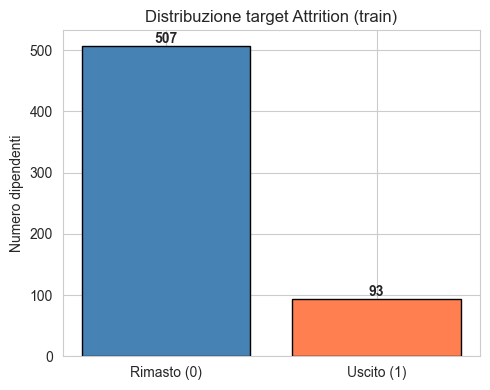

In [25]:
counts = train['Attrition'].value_counts().sort_index()
print('Distribuzione classi nel train set:')
print(counts)
print(f'\nPercentuale abbandono (classe 1): {counts[1] / len(train) * 100:.1f}%')

fig, ax = plt.subplots(figsize=(5, 4))
ax.bar(['Rimasto (0)', 'Uscito (1)'], counts.values,
       color=['steelblue', 'coral'], edgecolor='black')
for i, v in enumerate(counts.values):
    ax.text(i, v + 5, str(v), ha='center', fontweight='bold')
ax.set_title('Distribuzione target Attrition (train)')
ax.set_ylabel('Numero dipendenti')
plt.tight_layout()
plt.show()

### 4.2 Analisi dei Valori Mancanti

I missing values (slide p.24) possono essere gestiti con: eliminazione, stima (media/moda), o ignorati durante l'analisi.

In [26]:
def missing_report(df, name):
    miss = df.isnull().sum()
    miss_pct = (miss / len(df) * 100).round(2)
    report = pd.DataFrame({'Missing': miss, 'Missing_%': miss_pct})
    report = report[report['Missing'] > 0].sort_values('Missing', ascending=False)
    if len(report) == 0:
        print(f'{name}: nessun valore mancante.')
    else:
        print(f'{name}:')
        print(report)
    return report

miss_train = missing_report(train, 'Train')
print()
miss_test  = missing_report(test,  'Test')

Train:
                  Missing  Missing_%
Engagement_Score      108       18.0

Test:
                  Missing  Missing_%
Engagement_Score       27       18.0


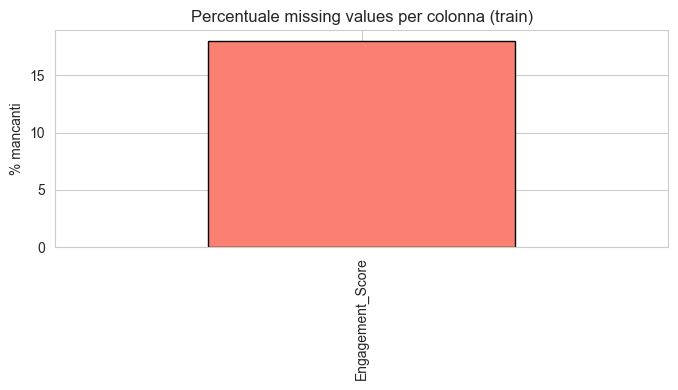


Nota: Engagement_Score manca nel ~18% dei casi.
Strategia: imputazione con la media calcolata sul train set.


In [27]:
if len(miss_train) > 0:
    fig, ax = plt.subplots(figsize=(7, 4))
    miss_train['Missing_%'].plot(kind='bar', ax=ax, color='salmon', edgecolor='black')
    ax.set_title('Percentuale missing values per colonna (train)')
    ax.set_ylabel('% mancanti')
    ax.set_xlabel('')
    plt.tight_layout()
    plt.show()

    print('\nNota: Engagement_Score manca nel ~18% dei casi.')
    print('Strategia: imputazione con la media calcolata sul train set.')

### 4.3 Analisi dei Duplicati

I dati duplicati (slide p.25) introducono bias e vanno rimossi quando non rappresentano eventi distinti.

In [28]:
n_dup_train = train.duplicated().sum()
n_dup_test  = test.duplicated().sum()
print(f'Righe duplicate nel train: {n_dup_train}')
print(f'Righe duplicate nel test:  {n_dup_test}')

Righe duplicate nel train: 0
Righe duplicate nel test:  0


### 4.4 Variabili a Varianza Zero o Quasi-Costanti

Le colonne con varianza nulla o quasi-nulla non forniscono informazione discriminante e andrebbero eliminate (feature selection — slide p.27).

In [29]:
num_cols = train.select_dtypes(include=[np.number]).columns.tolist()
variances = train[num_cols].var().sort_values()

print('=== Varianza per colonna numerica (crescente) ===')
print(variances.round(4))

zero_var = variances[variances == 0].index.tolist()
low_var  = variances[(variances > 0) & (variances < 0.01)].index.tolist()
print(f'\nColonne a varianza ZERO:    {zero_var}')
print(f'Colonne a varianza < 0.01:  {low_var}')

=== Varianza per colonna numerica (crescente) ===
Attrition                   1.312000e-01
PerformanceRating           1.380000e-01
Engagement_Score            2.000000e-01
WorkLifeBalance             5.183000e-01
JobInvolvement              5.431000e-01
StockOptionLevel            7.707000e-01
RelationshipSatisfaction    1.202800e+00
Education                   1.220600e+00
EnvironmentSatisfaction     1.223600e+00
JobSatisfaction             1.250400e+00
JobLevel                    1.349500e+00
Tenure_Instability          1.351200e+00
TrainingTimesLastYear       2.008300e+00
NumCompaniesWorked          6.324200e+00
YearsSinceLastPromotion     6.415900e+00
YearsInCurrentRole          9.820700e+00
YearsWithCurrManager        1.094940e+01
PercentSalaryHike           1.578360e+01
YearsAtCompany              3.243680e+01
TotalWorkingYears           5.353370e+01
DistanceFromHome            6.232450e+01
Age                         7.774180e+01
Random_Survey_Noise         1.463342e+02
HourlyR

In [30]:
if 'PerformanceRating' in train.columns:
    print('=== Analisi PerformanceRating ===')
    print(train['PerformanceRating'].value_counts())
    print(f'Valori unici: {sorted(train["PerformanceRating"].unique())}')
    print('Nota: se quasi costante (solo 2 valori con distribuzione molto asimmetrica), è candidata alla rimozione.')

=== Analisi PerformanceRating ===
PerformanceRating
3    501
4     99
Name: count, dtype: int64
Valori unici: [np.int64(3), np.int64(4)]
Nota: se quasi costante (solo 2 valori con distribuzione molto asimmetrica), è candidata alla rimozione.


### 4.5 Distribuzione delle Variabili Numeriche

Analizziamo la distribuzione di tutte le variabili numeriche chiave per identificare asimmetrie, code pesanti e potenziali outlier.

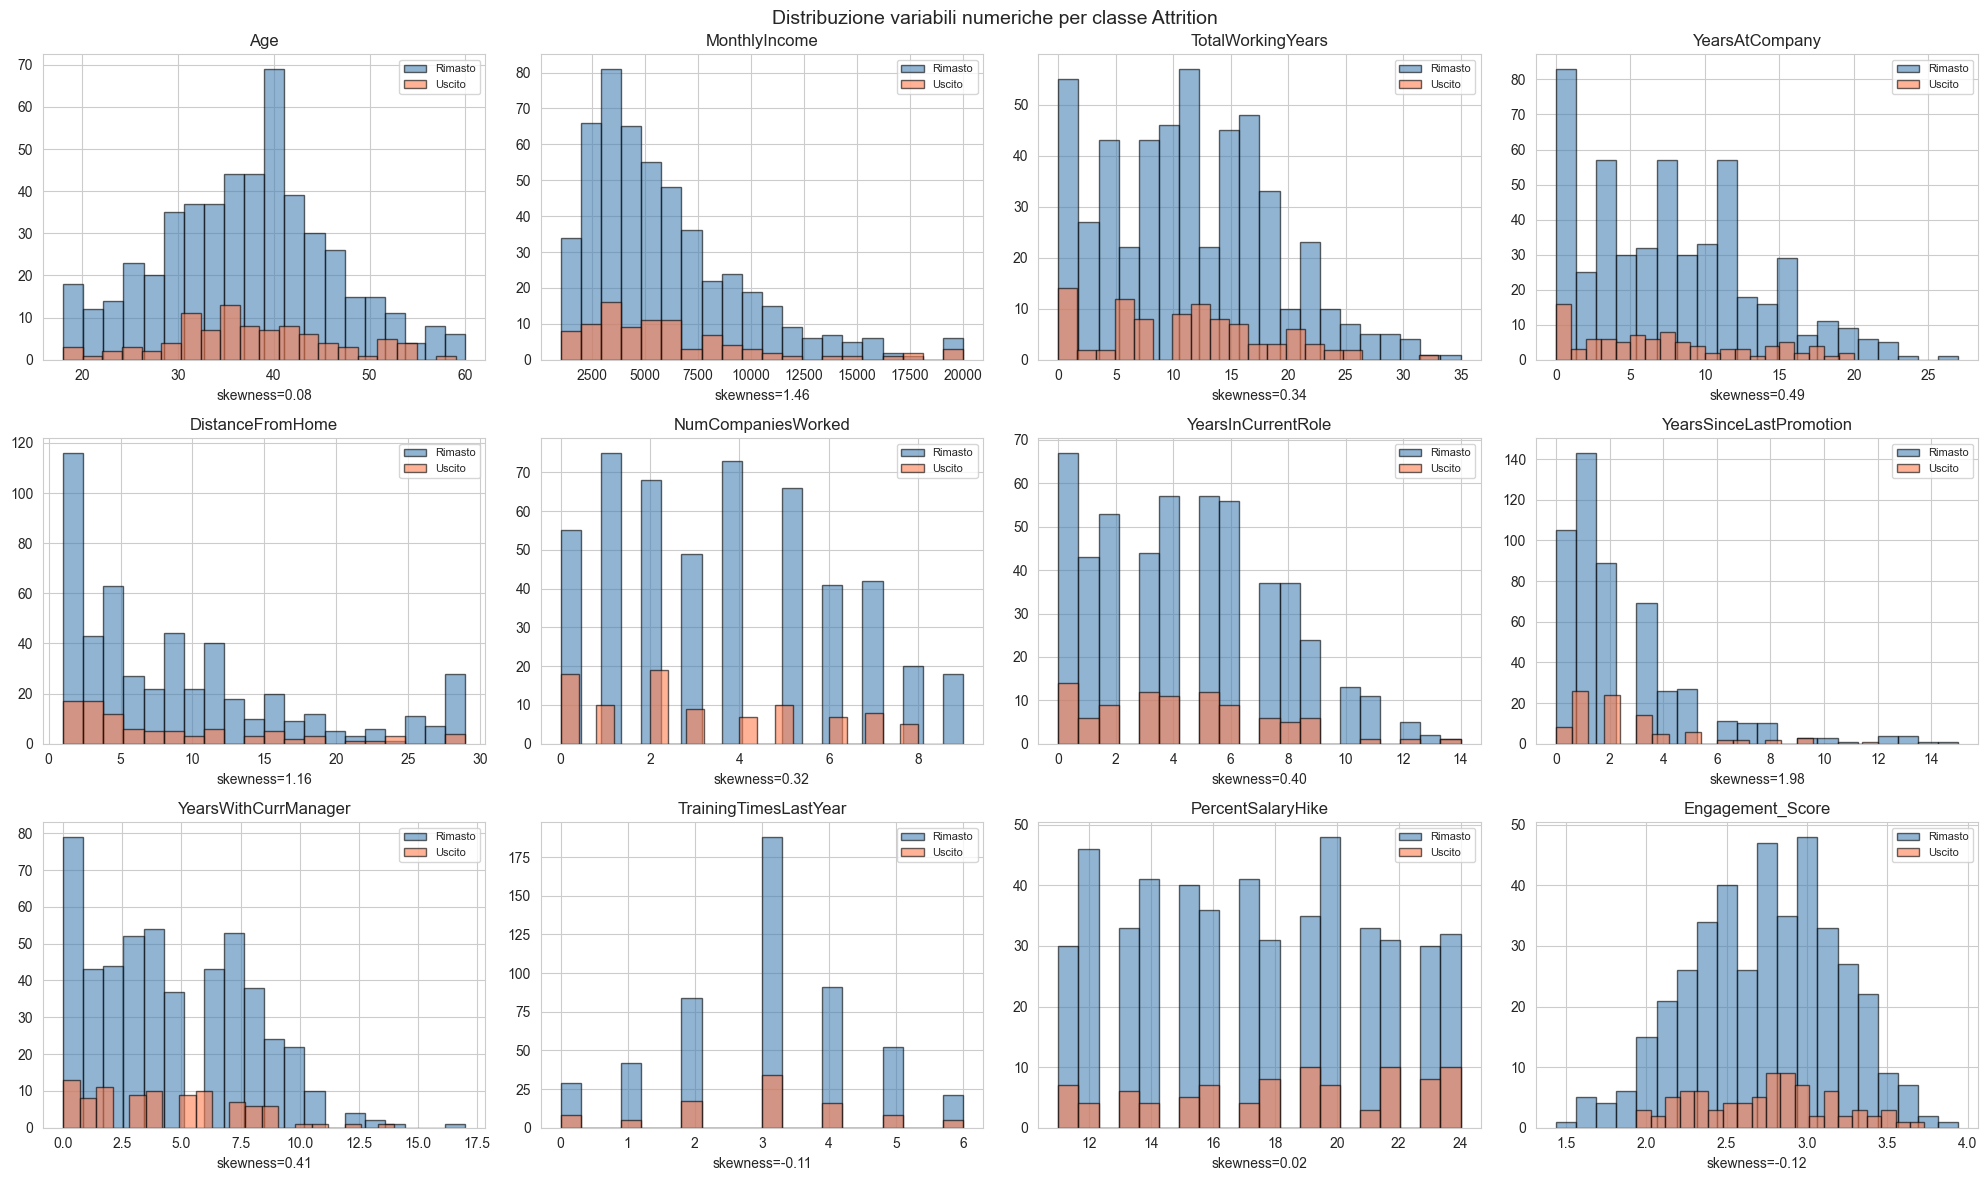

In [31]:
key_num = [c for c in ['Age', 'MonthlyIncome', 'TotalWorkingYears', 'YearsAtCompany',
                        'DistanceFromHome', 'NumCompaniesWorked', 'YearsInCurrentRole',
                        'YearsSinceLastPromotion', 'YearsWithCurrManager',
                        'TrainingTimesLastYear', 'PercentSalaryHike', 'Engagement_Score']
           if c in train.columns]

n_cols = 4
n_rows = (len(key_num) + n_cols - 1) // n_cols
fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, n_rows * 4))
axes = axes.flatten()

for i, feat in enumerate(key_num):
    data0 = train[train['Attrition'] == 0][feat].dropna()
    data1 = train[train['Attrition'] == 1][feat].dropna()
    axes[i].hist(data0, bins=20, alpha=0.6, label='Rimasto', color='steelblue', edgecolor='black')
    axes[i].hist(data1, bins=20, alpha=0.6, label='Uscito',  color='coral',     edgecolor='black')
    axes[i].set_title(feat)
    axes[i].legend(fontsize=8)
    skew_val = train[feat].skew()
    axes[i].set_xlabel(f'skewness={skew_val:.2f}')

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Distribuzione variabili numeriche per classe Attrition', fontsize=14)
plt.tight_layout()
plt.show()

### 4.6 Rilevamento Outlier — Metodo IQR

Gli **outlier** (slide p.23) sono oggetti con caratteristiche molto diverse dagli altri. Il metodo IQR identifica come outlier i valori fuori dall'intervallo $[Q1 - 1.5 \cdot IQR,\ Q3 + 1.5 \cdot IQR]$.

Nel contesto HR gli outlier non sono necessariamente errori: un dipendente con reddito molto alto è un caso reale. Verifichiamo quanti outlier ci sono e valutiamo caso per caso.

In [32]:
def count_outliers_iqr(series):
    Q1  = series.quantile(0.25)
    Q3  = series.quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    n_out = ((series < lower) | (series > upper)).sum()
    return n_out, lower, upper

print('=== Outlier per colonna numerica (metodo IQR) ===')
outlier_rows = []
for col in key_num:
    n_out, lo, up = count_outliers_iqr(train[col].dropna())
    pct = n_out / len(train) * 100
    outlier_rows.append({'Colonna': col, 'N_outlier': n_out,
                         '%_outlier': round(pct, 1), 'Lower': round(lo, 2), 'Upper': round(up, 2)})

df_out = pd.DataFrame(outlier_rows).sort_values('%_outlier', ascending=False)
df_out

=== Outlier per colonna numerica (metodo IQR) ===


,Colonna,N_outlier,%_outlier,Lower,Upper
7,YearsSinceLastPromotion,45,7.5,-2.00,6.00
1,MonthlyIncome,27,4.5,-3356.12,14112.88
4,DistanceFromHome,27,4.5,-12.00,28.00
6,YearsInCurrentRole,4,0.7,-4.38,12.62
2,TotalWorkingYears,3,0.5,-9.00,31.00
3,YearsAtCompany,2,0.3,-9.38,23.62
8,YearsWithCurrManager,1,0.2,-5.50,14.50
0,Age,0,0.0,13.00,61.00
5,NumCompaniesWorked,0,0.0,-5.00,11.00
9,TrainingTimesLastYear,0,0.0,-1.00,7.00


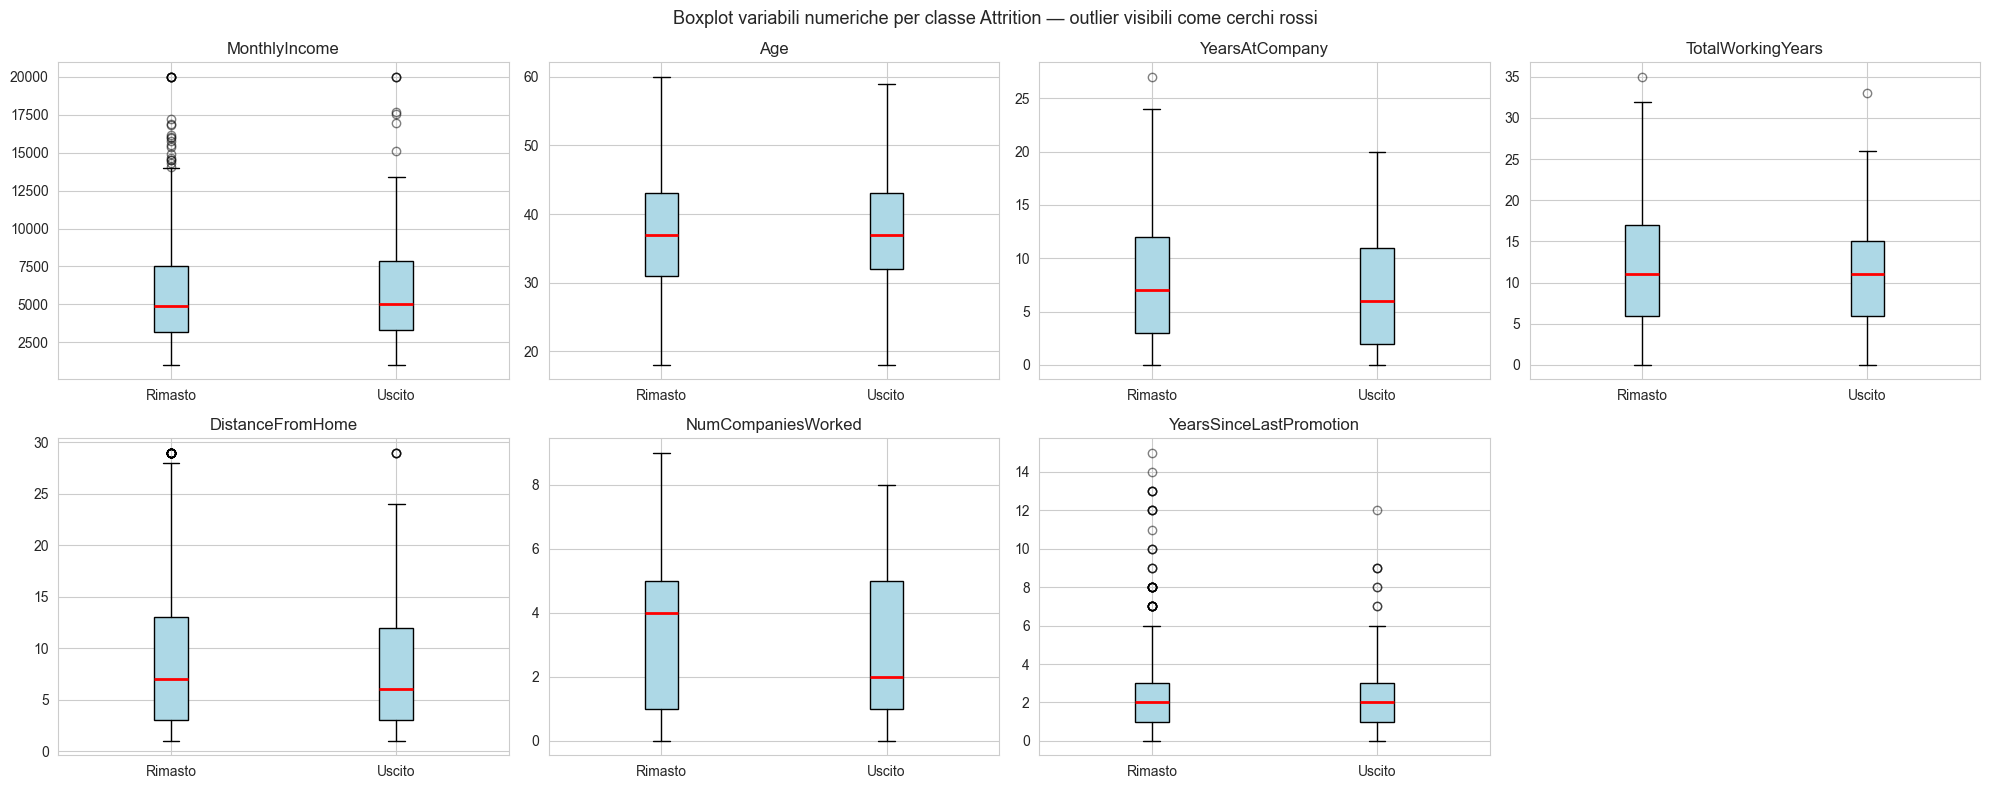

In [33]:
key_box = [c for c in ['MonthlyIncome', 'Age', 'YearsAtCompany', 'TotalWorkingYears',
                        'DistanceFromHome', 'NumCompaniesWorked', 'YearsSinceLastPromotion']
           if c in train.columns]

fig, axes = plt.subplots(2, 4, figsize=(20, 8))
axes = axes.flatten()

for i, feat in enumerate(key_box):
    data_0 = train[train['Attrition'] == 0][feat].dropna()
    data_1 = train[train['Attrition'] == 1][feat].dropna()
    axes[i].boxplot([data_0, data_1], labels=['Rimasto', 'Uscito'],
                    patch_artist=True,
                    boxprops=dict(facecolor='lightblue', color='black'),
                    medianprops=dict(color='red', linewidth=2),
                    flierprops=dict(marker='o', color='red', alpha=0.5))
    axes[i].set_title(feat)

for j in range(len(key_box), len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Boxplot variabili numeriche per classe Attrition — outlier visibili come cerchi rossi', fontsize=13)
plt.tight_layout()
plt.show()

### 4.7 Distribuzione Variabili Categoriche e Tasso di Abbandono

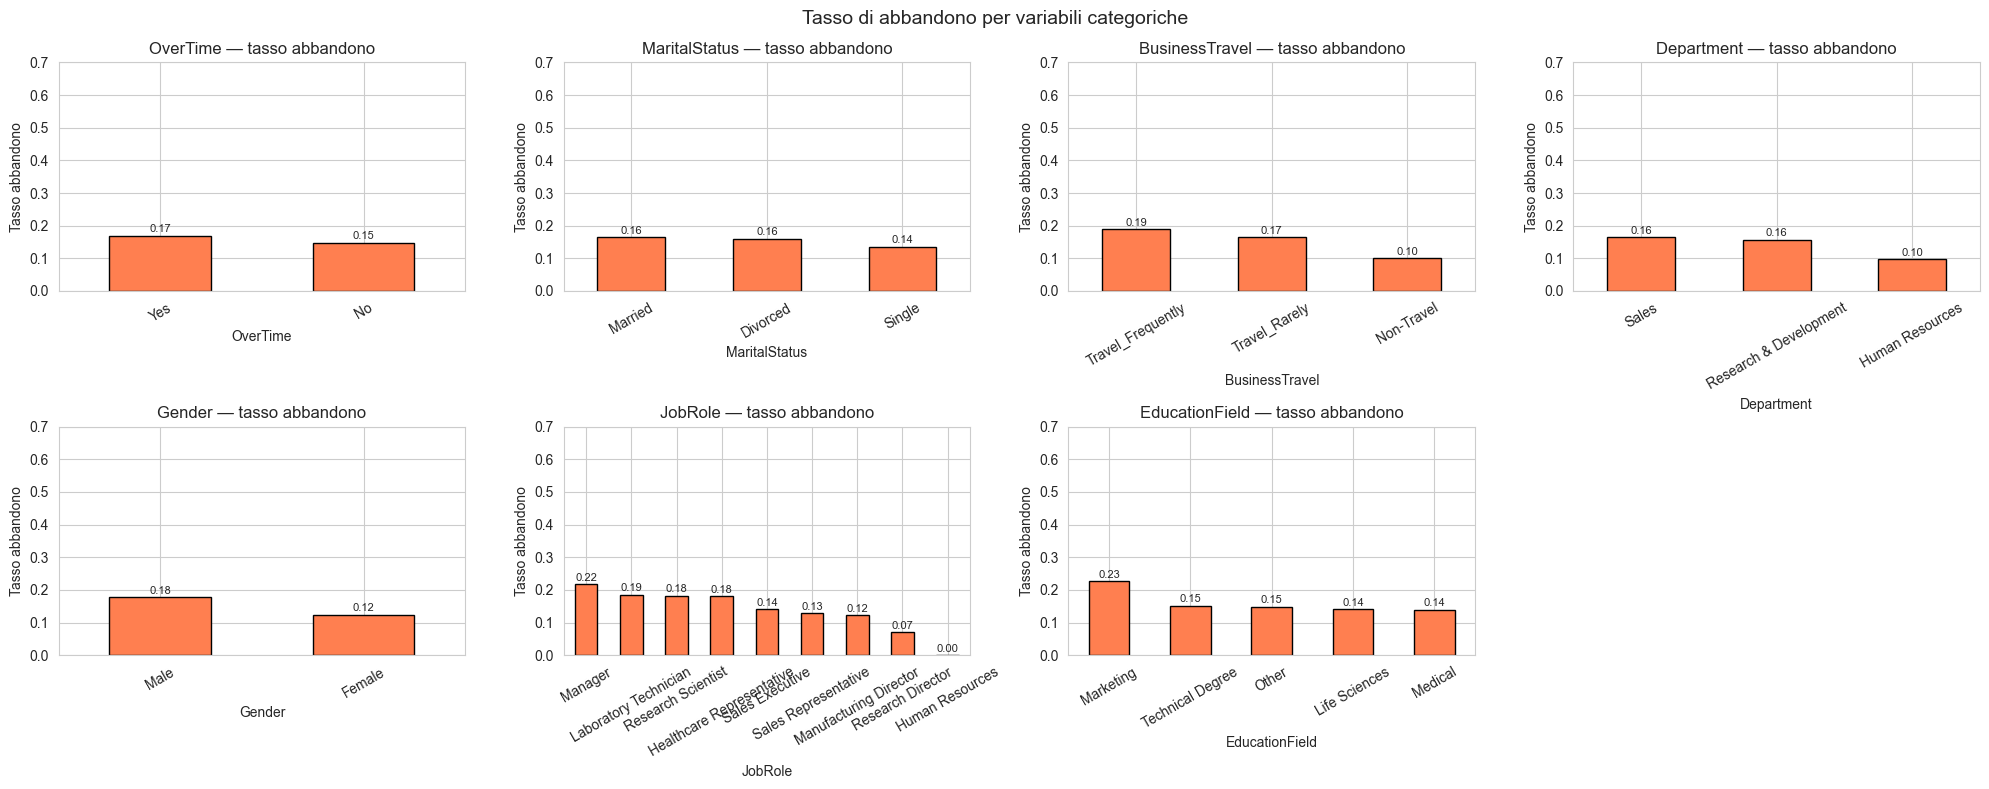

In [34]:
cat_to_plot = [c for c in ['OverTime', 'MaritalStatus', 'BusinessTravel',
                             'Department', 'Gender', 'JobRole', 'EducationField']
               if c in train.columns]

n_cols = 4
n_rows = (len(cat_to_plot) + n_cols - 1) // n_cols
fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, n_rows * 4))
axes = axes.flatten()

for i, feat in enumerate(cat_to_plot):
    att_rate = train.groupby(feat)['Attrition'].mean().sort_values(ascending=False)
    att_rate.plot(kind='bar', ax=axes[i], color='coral', edgecolor='black')
    axes[i].set_title(f'{feat} — tasso abbandono')
    axes[i].set_ylabel('Tasso abbandono')
    axes[i].set_ylim(0, 0.7)
    axes[i].tick_params(axis='x', rotation=30)
    for p in axes[i].patches:
        axes[i].annotate(f'{p.get_height():.2f}',
                         (p.get_x() + p.get_width() / 2, p.get_height() + 0.01),
                         ha='center', fontsize=8)

for j in range(len(cat_to_plot), len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Tasso di abbandono per variabili categoriche', fontsize=14)
plt.tight_layout()
plt.show()

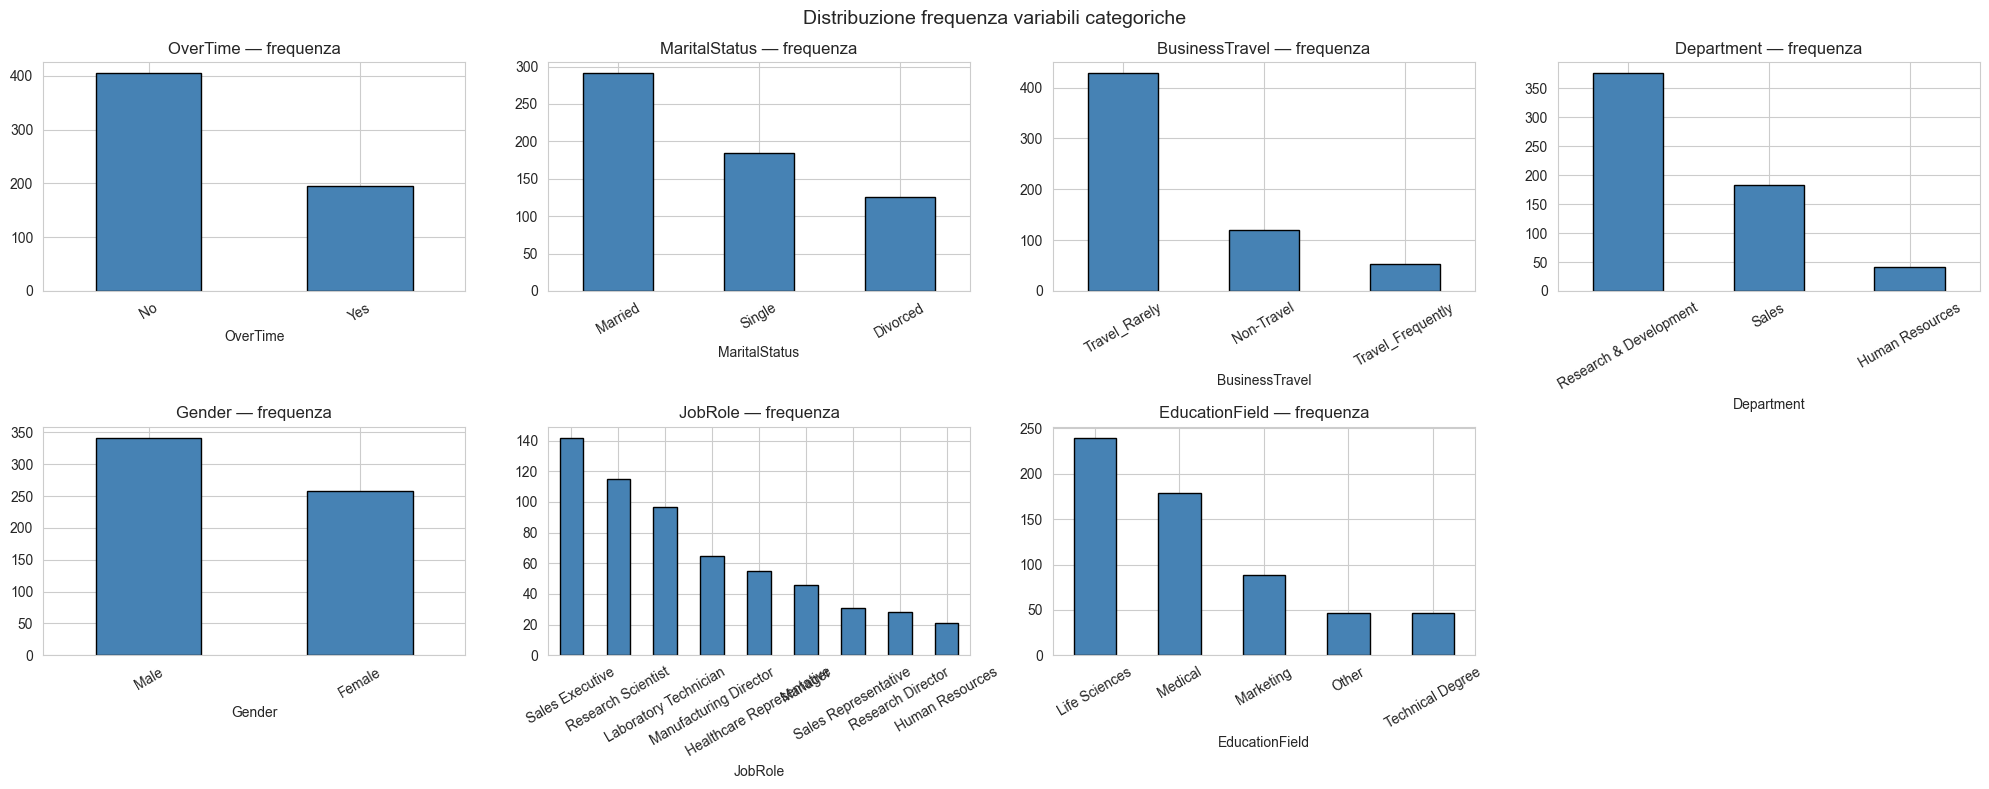

In [35]:
n_cols = 4
n_rows = (len(cat_to_plot) + n_cols - 1) // n_cols
fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, n_rows * 4))
axes = axes.flatten()

for i, feat in enumerate(cat_to_plot):
    vc = train[feat].value_counts()
    vc.plot(kind='bar', ax=axes[i], color='steelblue', edgecolor='black')
    axes[i].set_title(f'{feat} — frequenza')
    axes[i].tick_params(axis='x', rotation=30)

for j in range(len(cat_to_plot), len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Distribuzione frequenza variabili categoriche', fontsize=14)
plt.tight_layout()
plt.show()

### 4.8 Analisi di Correlazione

La correlazione alta tra due variabili (>0.85) indica ridondanza: una delle due potrebbe essere eliminata senza perdita di informazione (**feature subset selection** — slide p.27).

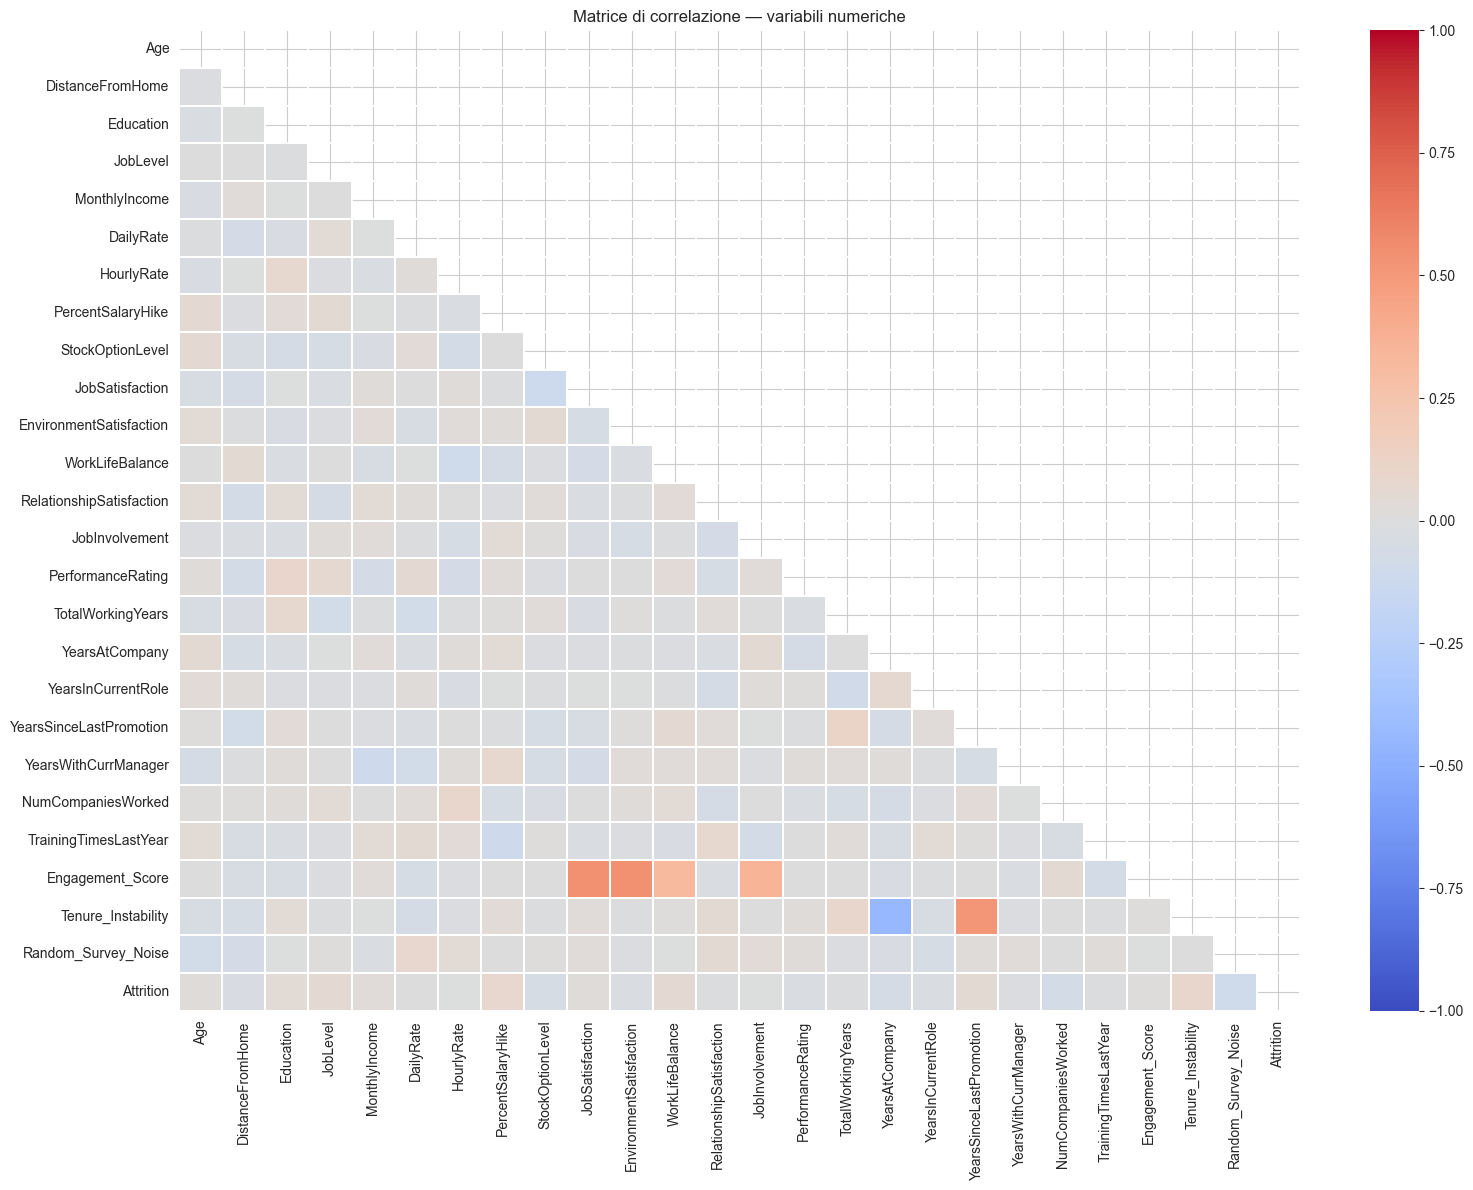

In [36]:
num_cols_all = train.select_dtypes(include=[np.number]).columns.tolist()
corr_matrix = train[num_cols_all].corr()

plt.figure(figsize=(16, 12))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, cmap='coolwarm', center=0,
            linewidths=0.3, annot=False, vmin=-1, vmax=1)
plt.title('Matrice di correlazione — variabili numeriche')
plt.tight_layout()
plt.show()

Top 15 variabili più correlate con Attrition:
Random_Survey_Noise       -0.100
Tenure_Instability         0.089
PercentSalaryHike          0.084
NumCompaniesWorked        -0.073
YearsAtCompany            -0.058
JobLevel                   0.057
WorkLifeBalance            0.057
StockOptionLevel          -0.047
YearsSinceLastPromotion    0.047
Education                  0.039
DistanceFromHome          -0.034
EnvironmentSatisfaction   -0.030
PerformanceRating         -0.029
YearsInCurrentRole        -0.027
MonthlyIncome              0.027
Name: Attrition, dtype: float64


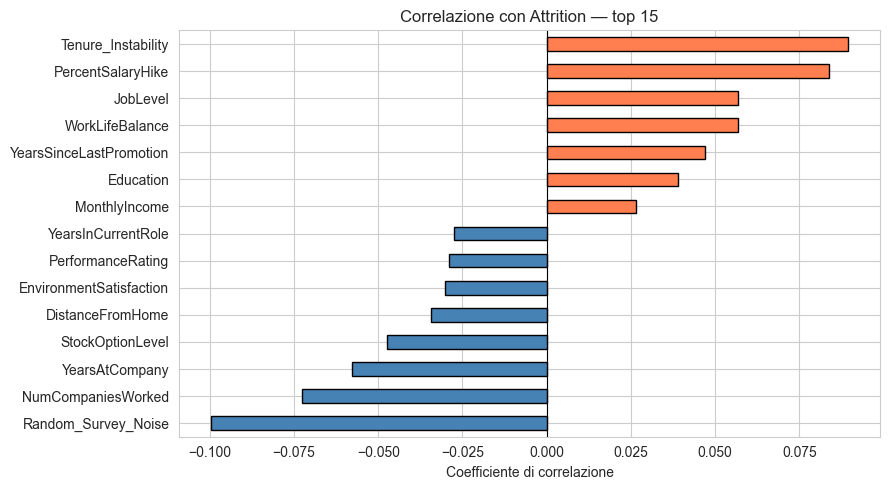

In [37]:
corr_target = corr_matrix['Attrition'].drop('Attrition').sort_values(key=abs, ascending=False)
print('Top 15 variabili più correlate con Attrition:')
print(corr_target.head(15).round(3))

plt.figure(figsize=(9, 5))
top15 = corr_target.head(15).sort_values()
colors = ['coral' if x > 0 else 'steelblue' for x in top15]
top15.plot(kind='barh', color=colors, edgecolor='black')
plt.axvline(0, color='black', linewidth=0.8)
plt.title('Correlazione con Attrition — top 15')
plt.xlabel('Coefficiente di correlazione')
plt.tight_layout()
plt.show()

In [38]:
THRESHOLD = 0.80
print(f'=== Coppie di variabili con |correlazione| > {THRESHOLD} ===')
high_corr = []
for i in range(len(corr_matrix.columns)):
    for j in range(i + 1, len(corr_matrix.columns)):
        c = corr_matrix.iloc[i, j]
        if abs(c) > THRESHOLD:
            high_corr.append({
                'Var1': corr_matrix.columns[i],
                'Var2': corr_matrix.columns[j],
                'Correlazione': round(c, 3)
            })

if not high_corr:
    print(f'Nessuna coppia con |correlazione| > {THRESHOLD}.')
    print('Proviamo con soglia 0.60:')
    for i in range(len(corr_matrix.columns)):
        for j in range(i + 1, len(corr_matrix.columns)):
            c = corr_matrix.iloc[i, j]
            if abs(c) > 0.60:
                high_corr.append({
                    'Var1': corr_matrix.columns[i],
                    'Var2': corr_matrix.columns[j],
                    'Correlazione': round(c, 3)
                })

if high_corr:
    df_hc = pd.DataFrame(high_corr)
    df_hc['_abs'] = df_hc['Correlazione'].abs()
    df_hc = df_hc.sort_values('_abs', ascending=False).drop(columns='_abs').reset_index(drop=True)
    print(df_hc.to_string(index=False))
else:
    print('Nessuna coppia con alta correlazione trovata.')

=== Coppie di variabili con |correlazione| > 0.8 ===
Nessuna coppia con |correlazione| > 0.8.
Proviamo con soglia 0.60:
Nessuna coppia con alta correlazione trovata.


### 4.9 Analisi Dettagliata delle Colonne Candidate alla Rimozione

Esaminiamo le colonne sospette una per una:

| Colonna | Motivo sospetto | Decisione |
|---|---|---|
| `Random_Survey_Noise` | Dichiarata esplicitamente come rumore | **Eliminare** |
| `Tenure_Instability` | Feature artificiale calcolata su dati anni — da valutare | **Analizzare** |
| `PerformanceRating` | Spesso quasi costante (3-4) in dataset IBM-HR | **Analizzare** |
| Coppie altamente correlate | Ridondanza informativa | **Una delle due** |

=== Analisi Tenure_Instability ===
count    600.0000
mean       0.6086
std        1.1624
min       -0.1190
25%        0.0680
50%        0.2300
75%        0.5638
max       10.0250
Name: Tenure_Instability, dtype: float64

Valori negativi: 57
Skewness: 4.040

Correlazione Tenure_Instability con altre variabili (top 8):
YearsSinceLastPromotion     0.518
YearsAtCompany             -0.444
TotalWorkingYears           0.091
Attrition                   0.089
DailyRate                  -0.055
RelationshipSatisfaction    0.053
DistanceFromHome           -0.048
Age                        -0.046
Name: Tenure_Instability, dtype: float64


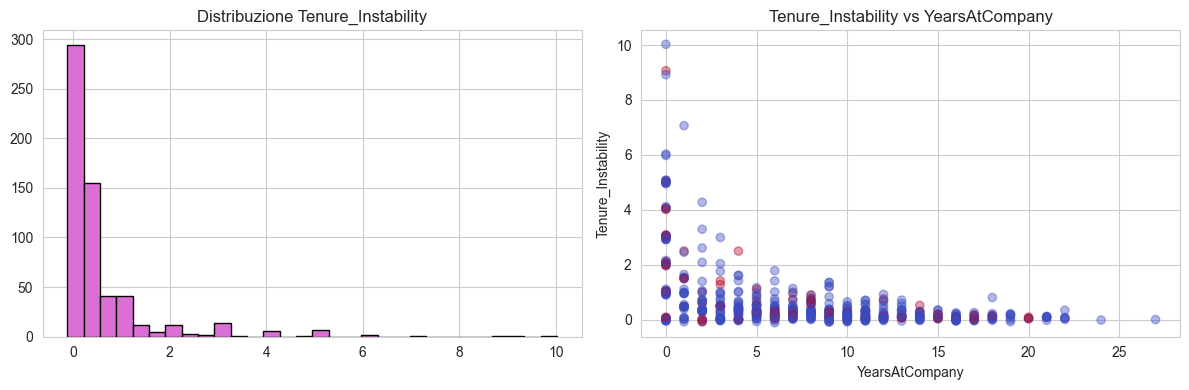

In [39]:
if 'Tenure_Instability' in train.columns:
    print('=== Analisi Tenure_Instability ===')
    print(train['Tenure_Instability'].describe().round(4))
    print(f'\nValori negativi: {(train["Tenure_Instability"] < 0).sum()}')
    print(f'Skewness: {train["Tenure_Instability"].skew():.3f}')

    ti_corr = corr_matrix['Tenure_Instability'].drop('Tenure_Instability').sort_values(key=abs, ascending=False)
    print('\nCorrelazione Tenure_Instability con altre variabili (top 8):')
    print(ti_corr.head(8).round(3))

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    axes[0].hist(train['Tenure_Instability'].dropna(), bins=30, edgecolor='black', color='orchid')
    axes[0].set_title('Distribuzione Tenure_Instability')
    axes[1].scatter(train['YearsAtCompany'], train['Tenure_Instability'],
                    c=train['Attrition'], cmap='coolwarm', alpha=0.4)
    axes[1].set_xlabel('YearsAtCompany')
    axes[1].set_ylabel('Tenure_Instability')
    axes[1].set_title('Tenure_Instability vs YearsAtCompany')
    plt.tight_layout()
    plt.show()

In [40]:
if 'Random_Survey_Noise' in train.columns:
    print('=== Analisi Random_Survey_Noise ===')
    print(train['Random_Survey_Noise'].describe().round(4))
    rn_corr = abs(corr_matrix['Random_Survey_Noise'].drop('Random_Survey_Noise'))
    print(f'\nMax correlazione assoluta con qualsiasi variabile: {rn_corr.max():.4f}')
    print(f'Correlazione con Attrition: {corr_matrix["Random_Survey_Noise"]["Attrition"]:.4f}')
    print('\nConferma: nessuna correlazione significativa → eliminare.')

=== Analisi Random_Survey_Noise ===
count    600.0000
mean      50.6819
std       12.0969
min        3.7200
25%       42.8825
50%       50.7300
75%       58.6300
max       85.1600
Name: Random_Survey_Noise, dtype: float64

Max correlazione assoluta con qualsiasi variabile: 0.0997
Correlazione con Attrition: -0.0997

Conferma: nessuna correlazione significativa → eliminare.


In [41]:
ordinal_cols = [c for c in ['Education', 'JobLevel', 'JobSatisfaction',
                              'EnvironmentSatisfaction', 'WorkLifeBalance',
                              'PerformanceRating', 'StockOptionLevel'] if c in train.columns]

print('=== Analisi variabili ordinali — value counts ===')
for col in ordinal_cols:
    vc = train[col].value_counts().sort_index()
    pct_max = vc.max() / len(train) * 100
    print(f'\n{col}: {dict(vc)} — categoria dominante: {pct_max:.1f}%')
    if pct_max > 90:
        print(f'  --> CANDIDATA ALLA RIMOZIONE (quasi costante)')

=== Analisi variabili ordinali — value counts ===

Education: {1: np.int64(75), 2: np.int64(124), 3: np.int64(227), 4: np.int64(128), 5: np.int64(46)} — categoria dominante: 37.8%

JobLevel: {1: np.int64(204), 2: np.int64(201), 3: np.int64(103), 4: np.int64(61), 5: np.int64(31)} — categoria dominante: 34.0%

JobSatisfaction: {1: np.int64(121), 2: np.int64(119), 3: np.int64(167), 4: np.int64(193)} — categoria dominante: 32.2%

EnvironmentSatisfaction: {1: np.int64(125), 2: np.int64(129), 3: np.int64(172), 4: np.int64(174)} — categoria dominante: 29.0%

WorkLifeBalance: {1: np.int64(32), 2: np.int64(156), 3: np.int64(346), 4: np.int64(66)} — categoria dominante: 57.7%

PerformanceRating: {3: np.int64(501), 4: np.int64(99)} — categoria dominante: 83.5%

StockOptionLevel: {0: np.int64(213), 1: np.int64(261), 2: np.int64(84), 3: np.int64(42)} — categoria dominante: 43.5%


### 4.10 Scatter Plot tra Variabili Chiave

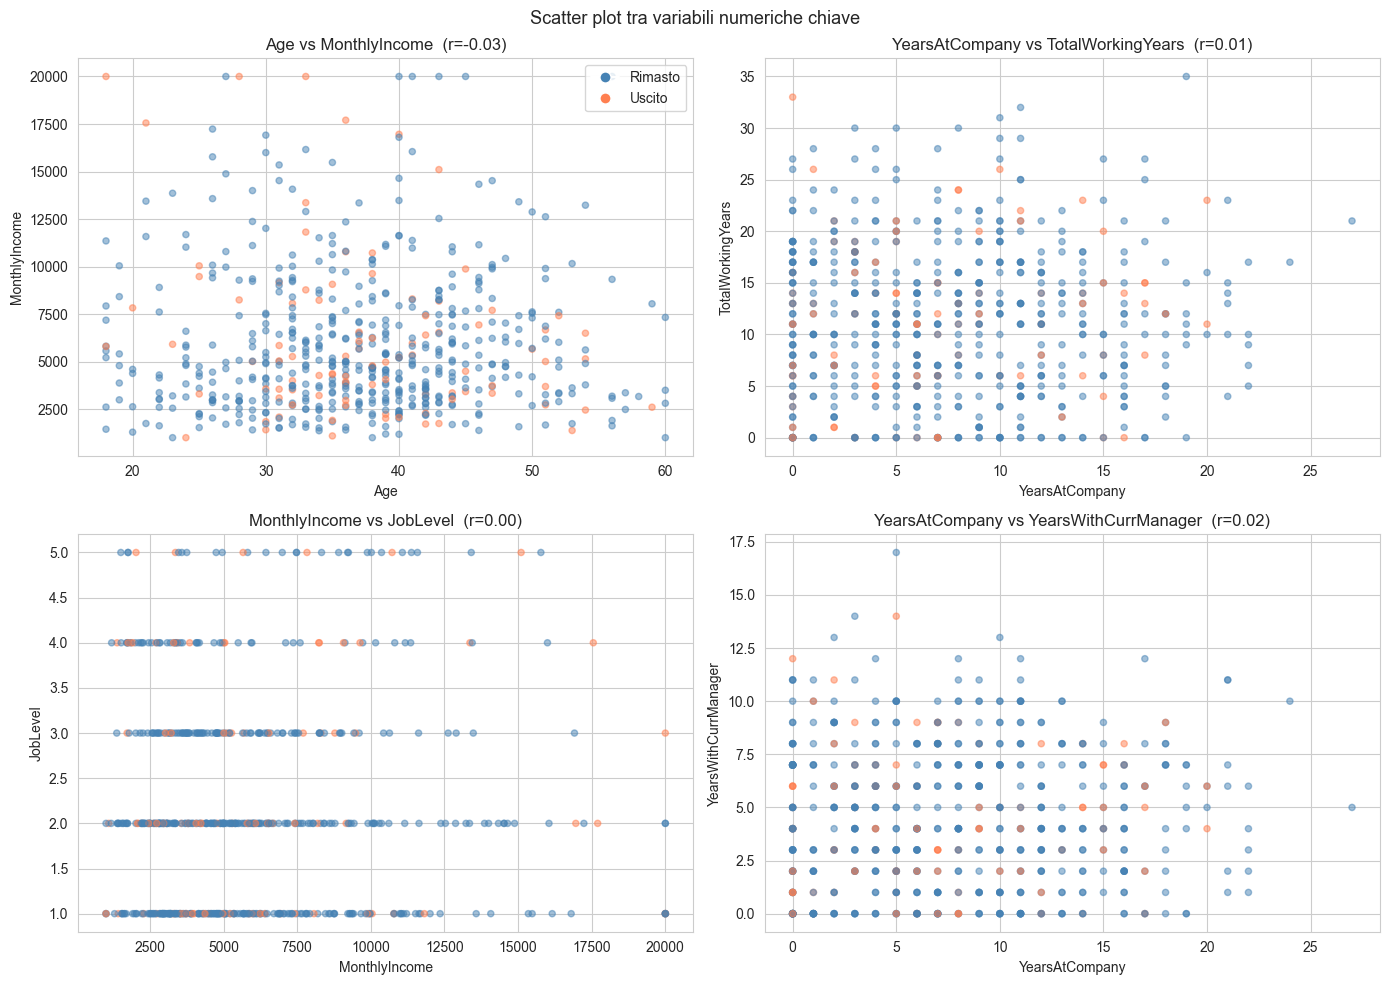

In [42]:
from matplotlib.colors import ListedColormap
cmap2 = ListedColormap(['steelblue', 'coral'])

pairs = [('Age', 'MonthlyIncome'), ('YearsAtCompany', 'TotalWorkingYears'),
         ('MonthlyIncome', 'JobLevel'), ('YearsAtCompany', 'YearsWithCurrManager')]

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for i, (x_col, y_col) in enumerate(pairs):
    if x_col in train.columns and y_col in train.columns:
        axes[i].scatter(train[x_col], train[y_col],
                        c=train['Attrition'], cmap=cmap2, alpha=0.5, s=20)
        axes[i].set_xlabel(x_col)
        axes[i].set_ylabel(y_col)
        axes[i].set_title(f'{x_col} vs {y_col}')
        corr_val = train[[x_col, y_col]].corr().iloc[0, 1]
        axes[i].set_title(f'{x_col} vs {y_col}  (r={corr_val:.2f})')

handles = [plt.Line2D([0],[0], marker='o', color='w', markerfacecolor='steelblue',
                        markersize=8, label='Rimasto'),
           plt.Line2D([0],[0], marker='o', color='w', markerfacecolor='coral',
                        markersize=8, label='Uscito')]
axes[0].legend(handles=handles)

plt.suptitle('Scatter plot tra variabili numeriche chiave', fontsize=13)
plt.tight_layout()
plt.show()

### 4.11 Riepilogo EDA — Decisioni di Preprocessing

| Azione | Colonne | Motivazione |
|---|---|---|
| **Eliminare** | `Random_Survey_Noise` | Rumore dichiarato esplicitamente, correlazione con Attrition ~0 |
| **Eliminare** | `PerformanceRating` | Quasi costante (solo valori 3-4), varianza ~0 |
| **Mantenere con attenzione** | `Tenure_Instability` | Feature artificiale ma potenzialmente informativa; alta corr. con anni |
| **Imputare** | `Engagement_Score` | Missing ~18% train → media del train |
| **Gestire outlier** | `MonthlyIncome`, `YearsAtCompany`, ... | Capping IQR-based (no rimozione: outlier reali in HR) |
| **Encoding** | variabili object | LabelEncoder (binarie) o OrdinalEncoder |

## 5. Data Preprocessing

Seguendo la pipeline delle slide (p.27): aggregazione, riduzione dimensionale, feature selection, trasformazione attributi.

### 5.1 Rimozione Colonne Irrilevanti o di Rumore

In [43]:
train_clean = train.copy()
test_clean  = test.copy()

cols_to_drop = ['Random_Survey_Noise']

if 'PerformanceRating' in train_clean.columns:
    pr_unique = sorted(train_clean['PerformanceRating'].unique())
    pr_dom_pct = train_clean['PerformanceRating'].value_counts().max() / len(train_clean) * 100
    print(f'PerformanceRating valori unici: {pr_unique}, categoria dominante: {pr_dom_pct:.1f}%')
    if pr_dom_pct > 85:
        cols_to_drop.append('PerformanceRating')
        print('  --> PerformanceRating aggiunta alle colonne da eliminare (quasi costante)')

cols_to_drop = [c for c in cols_to_drop if c in train_clean.columns]
train_clean = train_clean.drop(columns=cols_to_drop)
test_clean  = test_clean.drop(columns=cols_to_drop)

print(f'\nColonne eliminate: {cols_to_drop}')
print(f'Colonne rimanenti: {train_clean.shape[1]}')

PerformanceRating valori unici: [np.int64(3), np.int64(4)], categoria dominante: 83.5%

Colonne eliminate: ['Random_Survey_Noise']
Colonne rimanenti: 32


### 5.2 Gestione dei Valori Mancanti

Strategia: imputazione con la **media del train** per variabili numeriche, **moda del train** per categoriche. Il test set viene imputato con i parametri del train per evitare data leakage.

In [44]:
def fill_missing(df, ref=None):
    df = df.copy()
    src = ref if ref is not None else df
    for col in df.columns:
        if df[col].isnull().sum() == 0:
            continue
        if df[col].dtype in ['float64', 'int64']:
            fill_val = src[col].mean()
            print(f'  {col}: imputato con media = {fill_val:.3f}')
        else:
            fill_val = src[col].mode()[0]
            print(f'  {col}: imputato con moda = {fill_val}')
        df[col] = df[col].fillna(fill_val)
    return df

print('Imputazione train:')
train_clean = fill_missing(train_clean)
print('\nImputazione test (con parametri train):')
test_clean  = fill_missing(test_clean, ref=train_clean)

print(f'\nMissing values train: {train_clean.isnull().sum().sum()}')
print(f'Missing values test:  {test_clean.isnull().sum().sum()}')

Imputazione train:
  Engagement_Score: imputato con media = 2.735

Imputazione test (con parametri train):
  Engagement_Score: imputato con media = 2.735

Missing values train: 0
Missing values test:  0


### 5.3 Gestione Outlier — Capping IQR

Per le variabili con outlier significativi applichiamo **capping** (winsorization): i valori estremi vengono portati ai limiti IQR. Questo è preferibile alla rimozione di righe in contesti HR dove gli outlier rappresentano casi reali (dirigenti con alto reddito, dipendenti con molta anzianità).

Non applichiamo capping alle variabili ordinali (JobSatisfaction, ecc.) perché i loro range sono per definizione limitati.

In [45]:
ratio_cols = [c for c in ['MonthlyIncome', 'DistanceFromHome', 'NumCompaniesWorked',
                            'TotalWorkingYears', 'YearsAtCompany', 'YearsInCurrentRole',
                            'YearsSinceLastPromotion', 'YearsWithCurrManager',
                            'Engagement_Score', 'Tenure_Instability']
              if c in train_clean.columns]

cap_bounds = {}
for col in ratio_cols:
    Q1  = train_clean[col].quantile(0.25)
    Q3  = train_clean[col].quantile(0.75)
    IQR = Q3 - Q1
    lo  = Q1 - 1.5 * IQR
    hi  = Q3 + 1.5 * IQR
    cap_bounds[col] = (lo, hi)
    n_capped = ((train_clean[col] < lo) | (train_clean[col] > hi)).sum()
    if n_capped > 0:
        print(f'{col}: {n_capped} valori cappati in [{lo:.2f}, {hi:.2f}]')
    train_clean[col] = train_clean[col].clip(lower=lo, upper=hi)

for col, (lo, hi) in cap_bounds.items():
    if col in test_clean.columns:
        test_clean[col] = test_clean[col].clip(lower=lo, upper=hi)

print('\nCapping completato.')

MonthlyIncome: 27 valori cappati in [-3356.12, 14112.88]
DistanceFromHome: 27 valori cappati in [-12.00, 28.00]
TotalWorkingYears: 3 valori cappati in [-9.00, 31.00]
YearsAtCompany: 2 valori cappati in [-9.38, 23.62]
YearsInCurrentRole: 4 valori cappati in [-4.38, 12.62]
YearsSinceLastPromotion: 45 valori cappati in [-2.00, 6.00]
YearsWithCurrManager: 1 valori cappati in [-5.50, 14.50]
Engagement_Score: 11 valori cappati in [1.75, 3.72]
Tenure_Instability: 68 valori cappati in [-0.68, 1.31]

Capping completato.


### 5.4 Encoding delle Variabili Categoriche

Le variabili nominali vengono codificate con `LabelEncoder`. In alternativa si potrebbe usare One-Hot Encoding, ma per gli alberi decisionali il Label Encoding è sufficiente.

In [46]:
cat_cols = train_clean.select_dtypes(include='object').columns.tolist()
print(f'Variabili categoriche da codificare: {cat_cols}')

encoders = {}
for col in cat_cols:
    le = LabelEncoder()
    train_clean[col] = le.fit_transform(train_clean[col].astype(str))
    test_clean[col]  = test_clean[col].astype(str).map(
        lambda x, le=le: x if x in le.classes_ else le.classes_[0]
    )
    test_clean[col]  = le.transform(test_clean[col])
    encoders[col] = le
    print(f'  {col}: classi = {list(le.classes_)}')

Variabili categoriche da codificare: ['Gender', 'MaritalStatus', 'EducationField', 'Department', 'JobRole', 'BusinessTravel', 'OverTime']
  Gender: classi = ['Female', 'Male']
  MaritalStatus: classi = ['Divorced', 'Married', 'Single']
  EducationField: classi = ['Life Sciences', 'Marketing', 'Medical', 'Other', 'Technical Degree']
  Department: classi = ['Human Resources', 'Research & Development', 'Sales']
  JobRole: classi = ['Healthcare Representative', 'Human Resources', 'Laboratory Technician', 'Manager', 'Manufacturing Director', 'Research Director', 'Research Scientist', 'Sales Executive', 'Sales Representative']
  BusinessTravel: classi = ['Non-Travel', 'Travel_Frequently', 'Travel_Rarely']
  OverTime: classi = ['No', 'Yes']


### 5.5 Dataset Finale — Verifica

In [47]:
X_train = train_clean.drop(columns=['Attrition'])
y_train = train_clean['Attrition']

X_test  = test_clean.drop(columns=['Attrition'])
y_test  = test_clean['Attrition']

print('=== Dataset finale ===')
print(f'X_train: {X_train.shape}')
print(f'X_test:  {X_test.shape}')
print(f'Classe 1 (uscito) train: {y_train.sum()} / {len(y_train)} ({y_train.mean()*100:.1f}%)')
print(f'Classe 1 (uscito) test:  {y_test.sum()} / {len(y_test)} ({y_test.mean()*100:.1f}%)')
print(f'\nMissing: {X_train.isnull().sum().sum()}')
print(f'Tipo dati: {X_train.dtypes.value_counts().to_dict()}')

=== Dataset finale ===
X_train: (600, 31)
X_test:  (150, 31)
Classe 1 (uscito) train: 93 / 600 (15.5%)
Classe 1 (uscito) test:  23 / 150 (15.3%)

Missing: 0
Tipo dati: {dtype('int64'): 25, dtype('float64'): 6}


In [48]:
X_train.describe().T.round(3)

,count,mean,std,min,25%,50%,75%,max
Age,600.0,37.078,8.817,18.000,31.000,37.000,43.000,60.000
Gender,600.0,0.570,0.495,0.000,0.000,1.000,1.000,1.000
MaritalStatus,600.0,1.098,0.711,0.000,1.000,1.000,2.000,2.000
DistanceFromHome,600.0,8.923,7.782,1.000,3.000,6.000,13.000,28.000
Education,600.0,2.910,1.105,1.000,2.000,3.000,4.000,5.000
EducationField,600.0,1.285,1.274,0.000,0.000,1.000,2.000,4.000
Department,600.0,1.237,0.564,0.000,1.000,1.000,2.000,2.000
JobRole,600.0,4.475,2.462,0.000,2.000,5.000,7.000,8.000
JobLevel,600.0,2.190,1.162,1.000,1.000,2.000,3.000,5.000
BusinessTravel,600.0,1.515,0.805,0.000,1.000,2.000,2.000,2.000


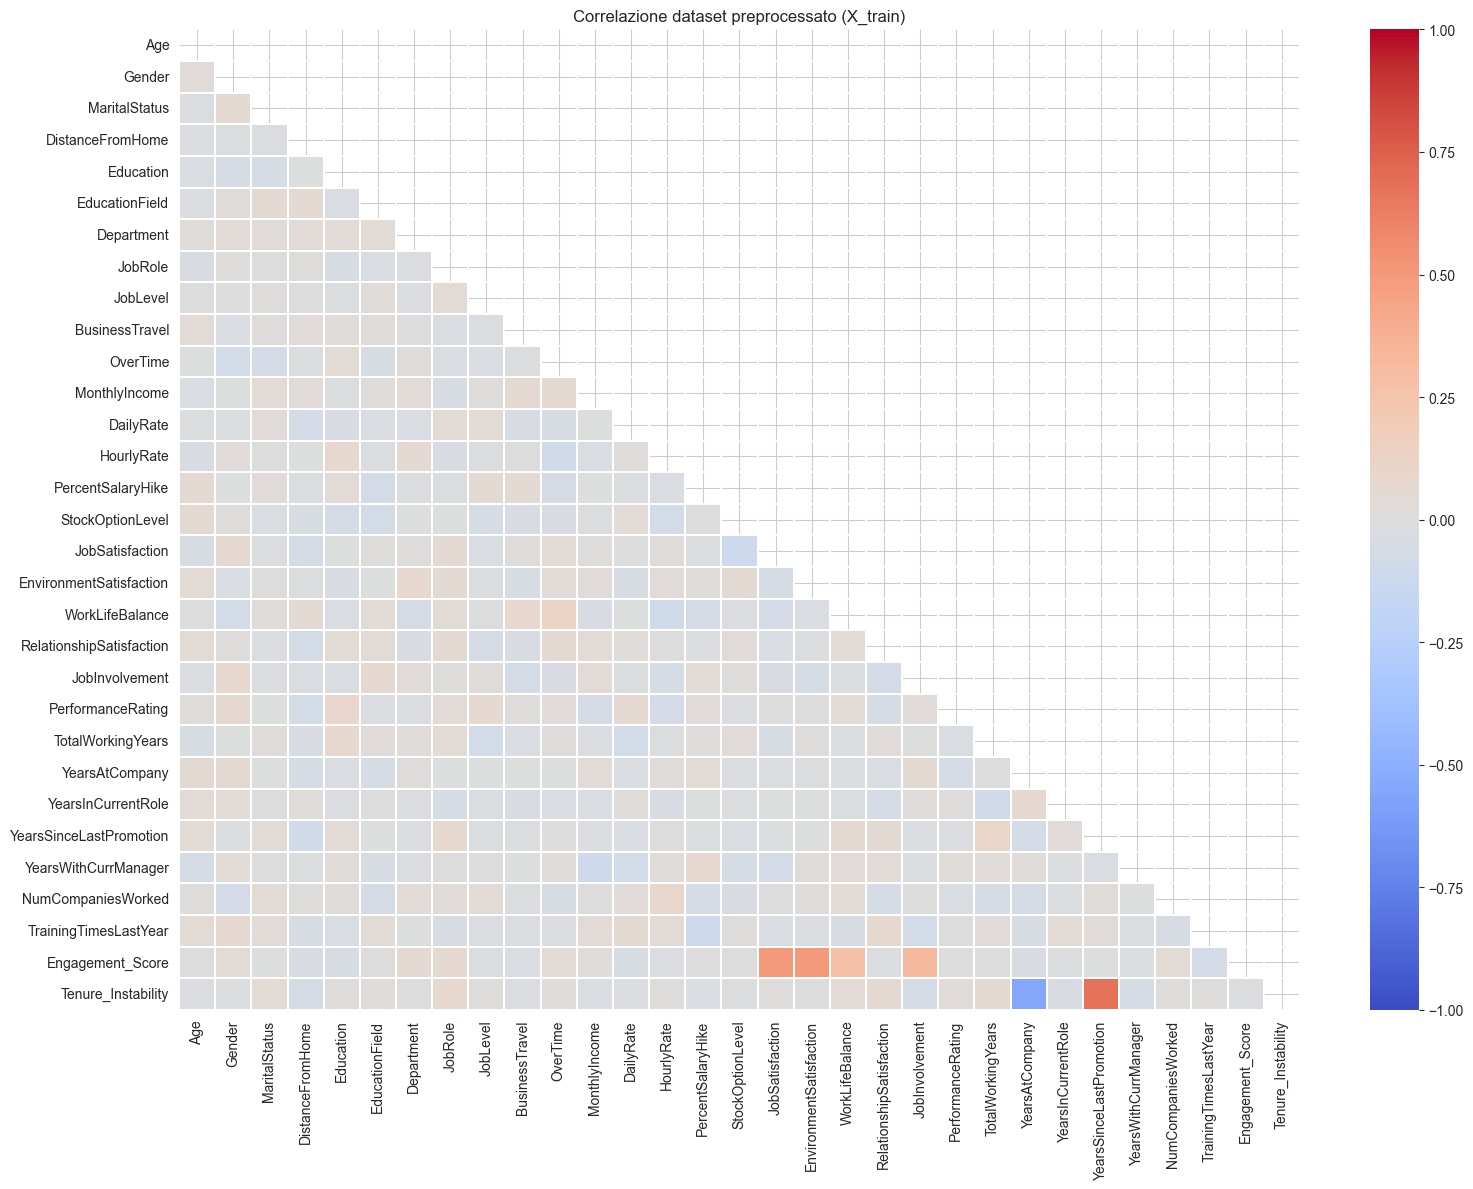

In [49]:
corr_final = X_train.corr()

plt.figure(figsize=(16, 12))
mask = np.triu(np.ones_like(corr_final, dtype=bool))
sns.heatmap(corr_final, mask=mask, cmap='coolwarm', center=0,
            linewidths=0.3, annot=False, vmin=-1, vmax=1)
plt.title('Correlazione dataset preprocessato (X_train)')
plt.tight_layout()
plt.show()

## 6. PCA — Principal Component Analysis

### Introduzione
Quando ci troviamo ad operare in situazioni in cui si hanno dati con un gran numero di dimensioni, è naturale pensare di proiettare questi dati in un sottospazio di dimensionalità inferiore, cercando di non perdere informazione importante sulle variabili originarie.

La **Principal Component Analysis** (PCA) è una tecnica finalizzata a ridurre la dimensionalità di un insieme di dati con finalità esplorativa o di visualizzazione dei dati, per un eventuale uso in analisi successive.

### Procedimento

Supponiamo di trovarci in uno spazio $\mathbb{R}^{d}$ e di volere una funzione lineare ${f}$ tali che ${f} : \mathbb{R}^d\rightarrow \mathbb{R}^e$ ma al contempo un'altra funzione lineare ${g}$ tali che ${g} : \mathbb{R}^e\rightarrow\mathbb{R}^d$, con ${e}$ < ${d}$.

Il nostro obbiettivo è quello di trovare le due migliori funzioni lineari che permettano di fare questo procedimento minimizzando la perdita di informazione:

$$\underset{U,V}{\text{argmin}} \sum_{i=1}^{m} \left\| p_i - {VU}p_i \right\|^2_2$$

La soluzione è data dagli **autovettori** della matrice di covarianza $A = X^T X$, ordinati per autovalore decrescente.

### Varianza Spiegata

La varianza spiegata dall'i-esima componente principale è $\lambda_i$, e la proporzione è:
$$\text{PVE}_i = \frac{\lambda_i}{\sum_{j}\lambda_j}$$

La varianza cumulata (CPVE) indica quanta varianza totale è rappresentata fino alla PC $k$:
$$\text{CPVE}_k = \frac{\sum_{i=1}^{k}\lambda_i}{\sum_{j}\lambda_j}$$

### 6.1 Preparazione — Scaling e Split

In [50]:
x = X_train.values
y = y_train.values

scaler_pca = StandardScaler()
scaler_pca.fit(x)
X_scaled = scaler_pca.transform(x)

print(f'Shape X_scaled: {X_scaled.shape}')
print(f'Media (deve essere ~0): {X_scaled.mean(axis=0).round(4)[:5]} ...')
print(f'Std   (deve essere ~1): {X_scaled.std(axis=0).round(4)[:5]} ...')

Shape X_scaled: (600, 31)
Media (deve essere ~0): [ 0.  0. -0. -0. -0.] ...
Std   (deve essere ~1): [1. 1. 1. 1. 1.] ...


### 6.2 Varianza Spiegata — Standardizzato vs Non Standardizzato

Confrontiamo la PCA su dati standardizzati (consigliato quando le variabili hanno scale diverse) e non standardizzati.

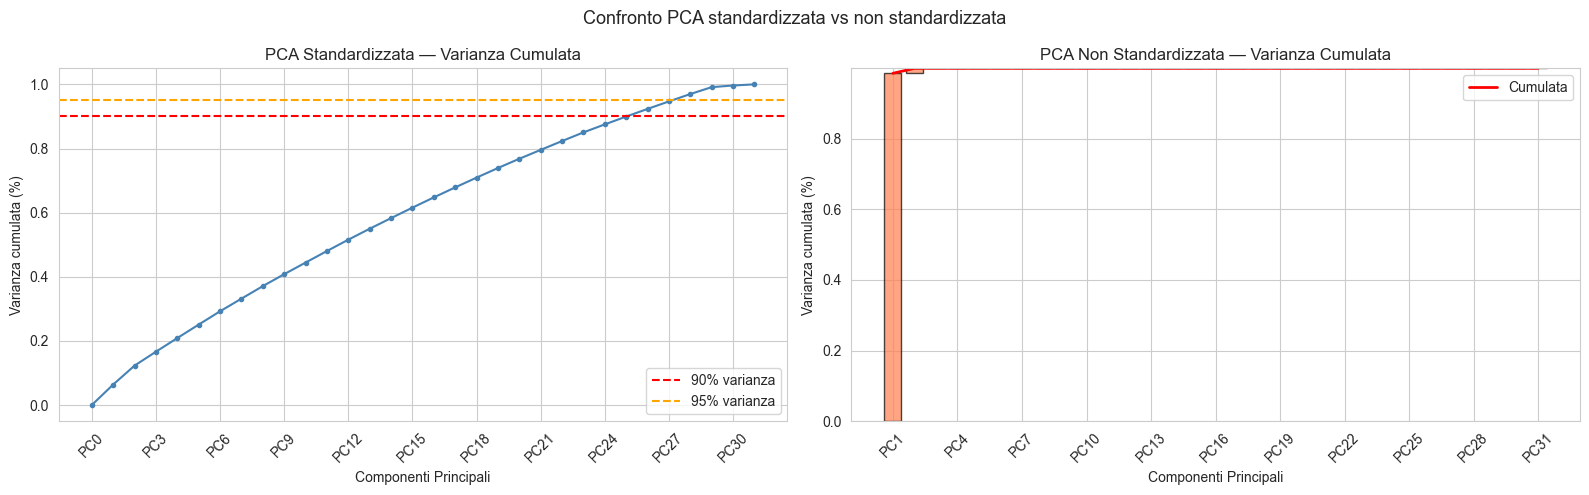


Nota: la PCA standardizzata distribuisce meglio la varianza tra le componenti.
Con dati non standardizzati le variabili ad alta scala dominano (es. MonthlyIncome).


In [51]:
pca_full     = PCA()
pca_full_nst = PCA()

pca_full.fit(X_scaled)
pca_full_nst.fit(x)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

cumvar_st = np.insert(np.cumsum(pca_full.explained_variance_ratio_), 0, 0)
axes[0].plot(cumvar_st, marker='o', markersize=3, color='steelblue')
axes[0].axhline(y=0.90, color='red', linestyle='--', label='90% varianza')
axes[0].axhline(y=0.95, color='orange', linestyle='--', label='95% varianza')
axes[0].set_title('PCA Standardizzata — Varianza Cumulata')
n_ticks = pca_full.n_components_
step = max(1, n_ticks // 10)
axes[0].set_xticks(np.arange(0, n_ticks + 1, step))
axes[0].set_xticklabels([f'PC{i}' for i in range(0, n_ticks + 1, step)], rotation=45)
axes[0].set_xlabel('Componenti Principali')
axes[0].set_ylabel('Varianza cumulata (%)')
axes[0].legend()
axes[0].grid(True)

cumvar_nst = np.cumsum(pca_full_nst.explained_variance_ratio_)
axes[1].bar(np.arange(pca_full_nst.n_components_),
            pca_full_nst.explained_variance_ratio_,
            bottom=np.insert(cumvar_nst, 0, 0)[:-1],
            color='coral', edgecolor='black', alpha=0.7)
axes[1].plot(cumvar_nst, 'r', linewidth=2, label='Cumulata')
axes[1].set_title('PCA Non Standardizzata — Varianza Cumulata')
step_nst = max(1, pca_full_nst.n_components_ // 10)
axes[1].set_xticks(np.arange(0, pca_full_nst.n_components_, step_nst))
axes[1].set_xticklabels([f'PC{i+1}' for i in range(0, pca_full_nst.n_components_, step_nst)], rotation=45)
axes[1].set_xlabel('Componenti Principali')
axes[1].set_ylabel('Varianza cumulata (%)')
axes[1].legend()
axes[1].grid(True)

plt.suptitle('Confronto PCA standardizzata vs non standardizzata', fontsize=13)
plt.tight_layout()
plt.show()

print('\nNota: la PCA standardizzata distribuisce meglio la varianza tra le componenti.')
print('Con dati non standardizzati le variabili ad alta scala dominano (es. MonthlyIncome).')

### 6.3 Scelta del Numero di Componenti Principali

Scegliamo il numero minimo di PC che spiegano almeno il **90%** della varianza totale.

In [52]:
explvar_p = 0.90
pca = PCA(explvar_p)
pca.fit(X_scaled)
X_pca_train = pca.transform(X_scaled)

X_scaled_full = scaler_pca.transform(X_train.values)
X_pca_all     = pca.transform(X_scaled_full)

df_pca_info = pd.DataFrame({
    'val': [pca.n_components_, round(pca.explained_variance_ratio_.sum() * 100, 2)]
}, index=['n. PC', 'Varianza spiegata (%)'])

print(df_pca_info)
print(f'\nRiduzione: da {X_train.shape[1]} feature a {pca.n_components_} componenti principali')
print(f'Varianza conservata: {pca.explained_variance_ratio_.sum()*100:.2f}%')

                         val
n. PC                  26.00
Varianza spiegata (%)  92.34

Riduzione: da 31 feature a 26 componenti principali
Varianza conservata: 92.34%


### 6.4 Score Graph — Proiezione dei Dati nello Spazio PCA

Il **score graph** mostra come i campioni si distribuiscono nelle prime due (o tre) componenti principali. I colori indicano la classe Attrition.

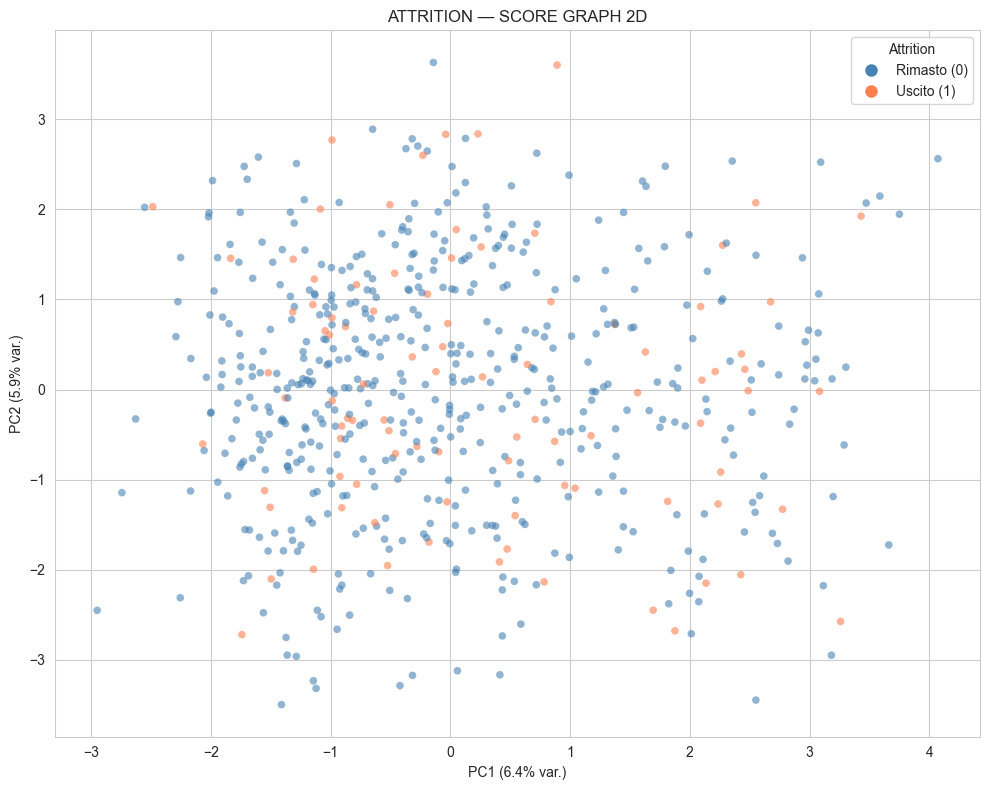

In [53]:
from matplotlib.colors import ListedColormap
cmap_pca = ListedColormap(['steelblue', 'coral'])

plt.figure(figsize=(10, 8))
scatter = plt.scatter(X_pca_train[:, 0], X_pca_train[:, 1],
                      c=y, cmap=cmap_pca, alpha=0.6, s=30, edgecolors='none')
plt.title('ATTRITION — SCORE GRAPH 2D')
plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% var.)')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% var.)')
handles = [plt.Line2D([0],[0], marker='o', color='w', markerfacecolor='steelblue',
                        markersize=10, label='Rimasto (0)'),
           plt.Line2D([0],[0], marker='o', color='w', markerfacecolor='coral',
                        markersize=10, label='Uscito (1)')]
plt.legend(handles=handles, title='Attrition')
plt.grid(True)
plt.tight_layout()
plt.show()

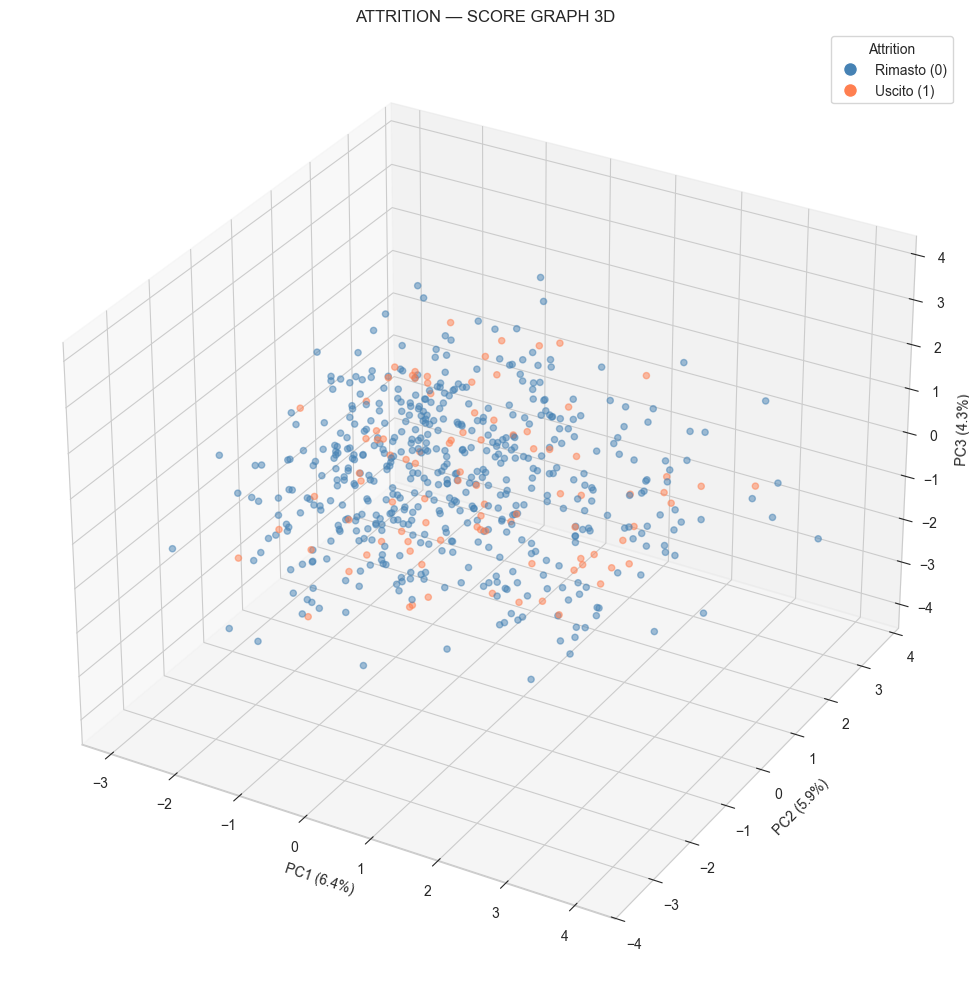

In [54]:
fig = plt.figure(figsize=(12, 10))
ax  = fig.add_subplot(111, projection='3d')

colors_3d = ['steelblue' if yi == 0 else 'coral' for yi in y]
ax.scatter(X_pca_train[:, 0], X_pca_train[:, 1], X_pca_train[:, 2],
           c=colors_3d, alpha=0.5, s=20)

ax.set_title('ATTRITION — SCORE GRAPH 3D')
ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)')
ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)')
ax.set_zlabel(f'PC3 ({pca.explained_variance_ratio_[2]*100:.1f}%)')

handles_3d = [plt.Line2D([0],[0], marker='o', color='w', markerfacecolor='steelblue',
                          markersize=10, label='Rimasto (0)'),
              plt.Line2D([0],[0], marker='o', color='w', markerfacecolor='coral',
                          markersize=10, label='Uscito (1)')]
ax.legend(handles=handles_3d, title='Attrition')
plt.grid(True)
plt.tight_layout()
plt.show()

### 6.5 Loading Graph — Contributo delle Feature alle PC

Il **loading graph** mostra la correlazione tra le feature originali e le componenti principali. Ogni vettore rappresenta una feature: la sua direzione indica il contributo a PC1 e PC2.

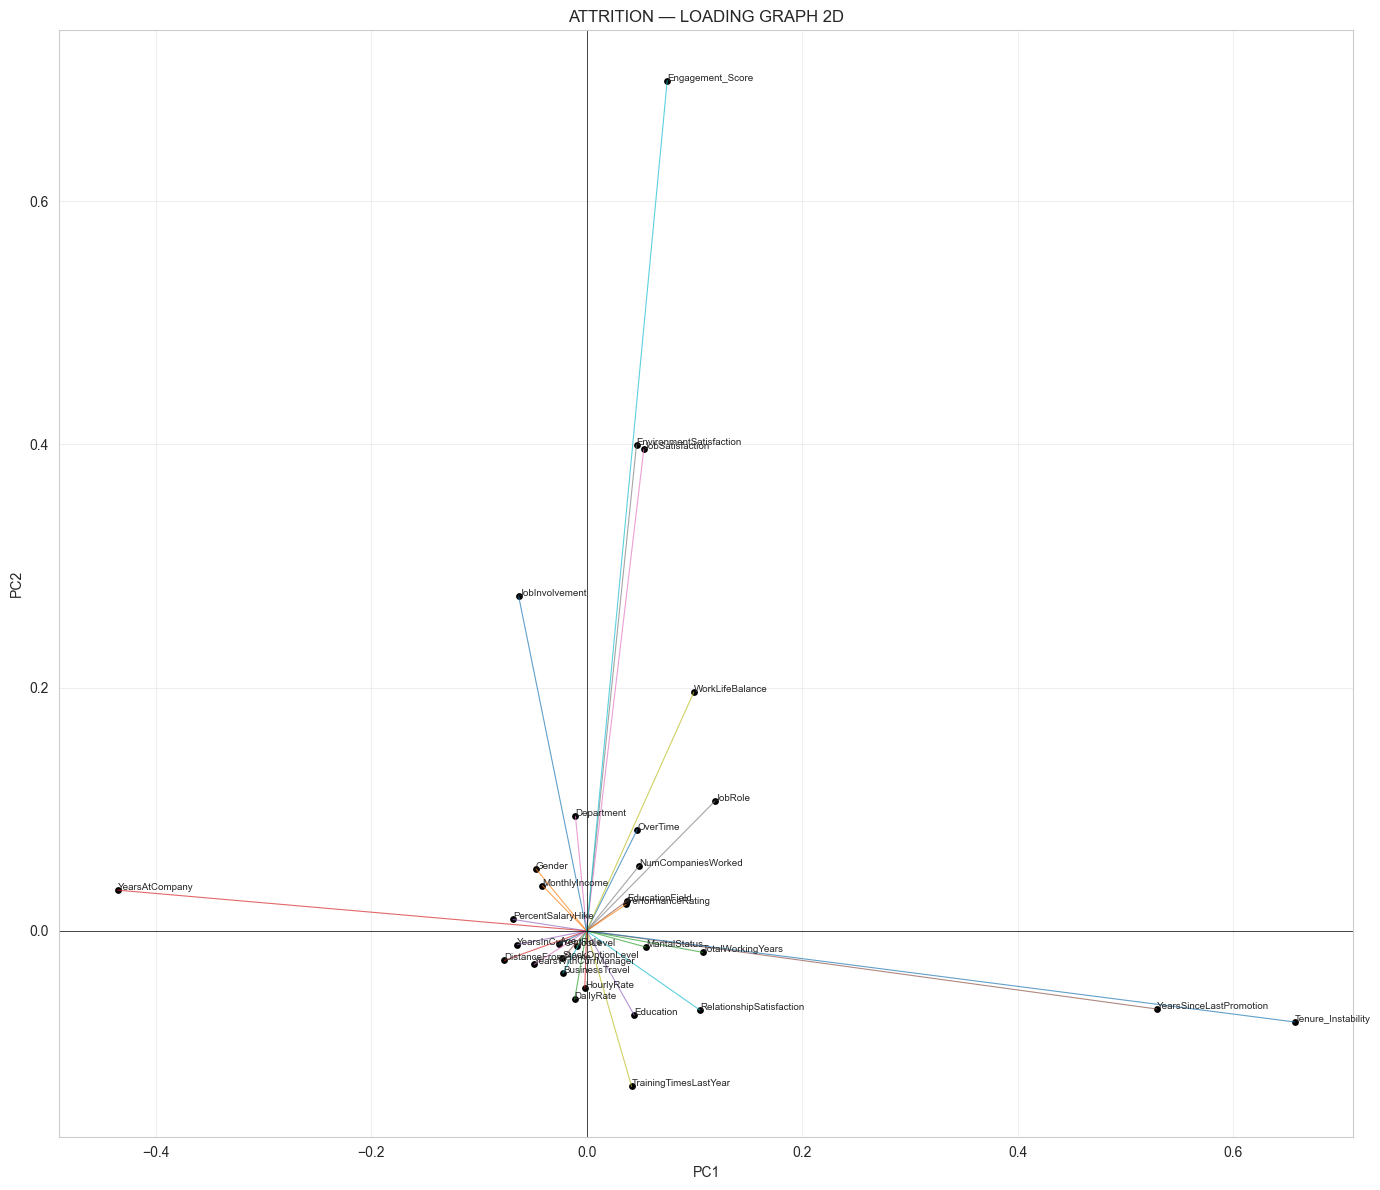

In [55]:
feature_names = X_train.columns.tolist()
n_feat = len(feature_names)

plt.figure(figsize=(14, 12))
for i in range(n_feat):
    plt.plot([0, pca.components_[0, i]], [0, pca.components_[1, i]],
             alpha=0.7, linewidth=0.8)
    plt.scatter(pca.components_[0, i], pca.components_[1, i], c='black', s=15)
    plt.annotate(feature_names[i],
                 (pca.components_[0, i], pca.components_[1, i]),
                 fontsize=7, ha='left')

plt.title('ATTRITION — LOADING GRAPH 2D')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.axhline(0, color='black', linewidth=0.5)
plt.axvline(0, color='black', linewidth=0.5)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

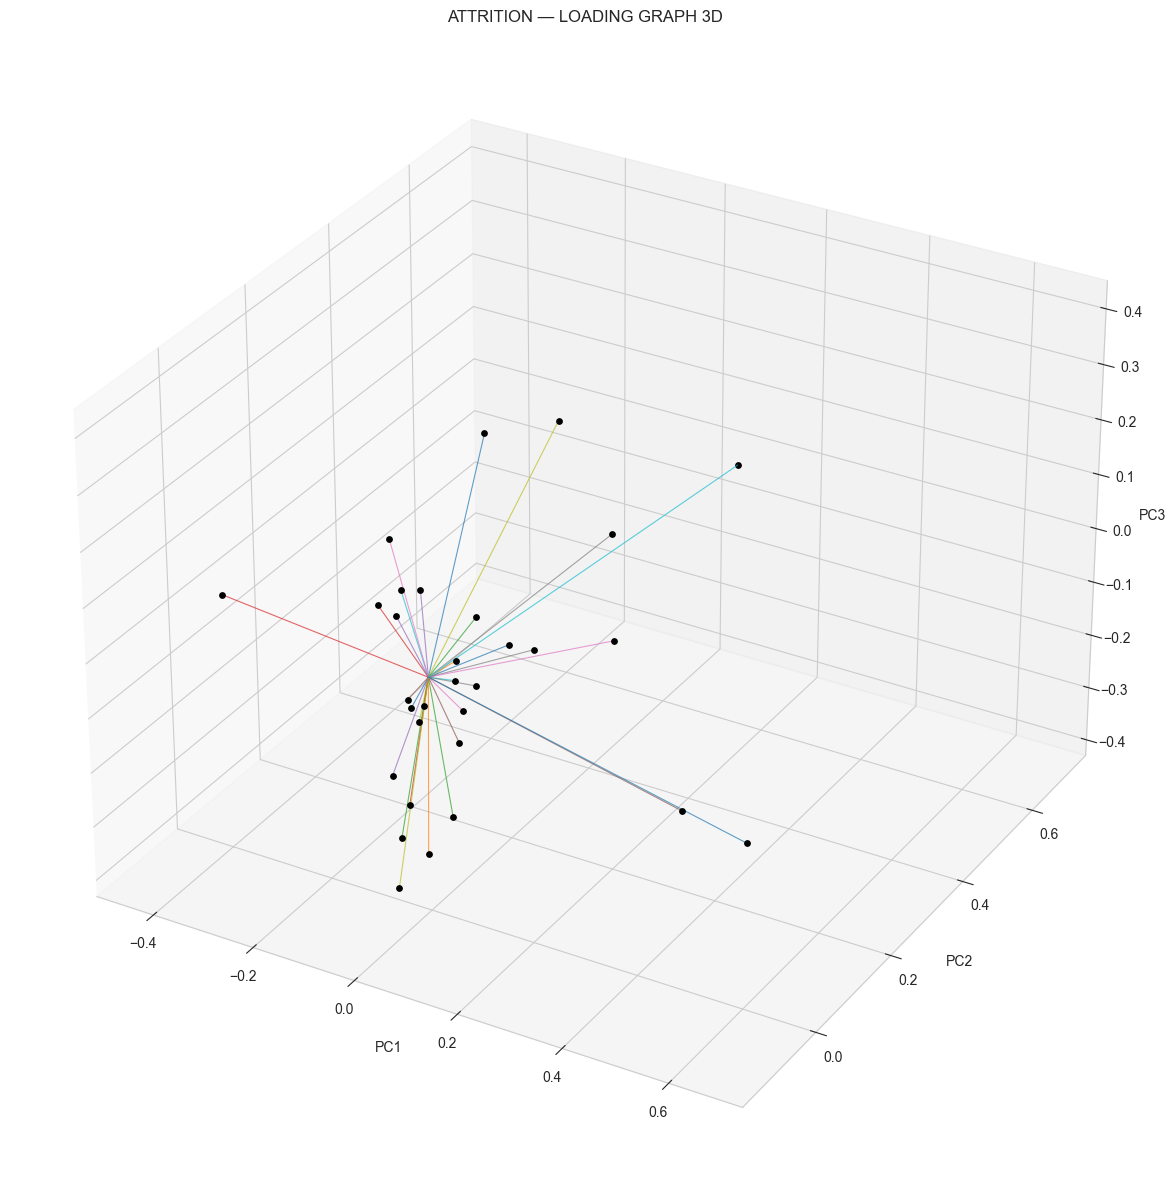

In [56]:
fig = plt.figure(figsize=(14, 12))
ax  = fig.add_subplot(111, projection='3d')

for i in range(n_feat):
    ax.plot([0, pca.components_[0, i]],
            [0, pca.components_[1, i]],
            [0, pca.components_[2, i]], alpha=0.7, linewidth=0.8)
    ax.scatter(pca.components_[0, i], pca.components_[1, i],
               pca.components_[2, i], c='black', s=15)

ax.set_title('ATTRITION — LOADING GRAPH 3D')
ax.set_xlabel('PC1')
ax.set_ylabel('PC2')
ax.set_zlabel('PC3')
plt.grid(True)
plt.tight_layout()
plt.show()

### 6.6 Barplot dei Loading — Contributo Feature per PC1 e PC2

Il barplot mostra quantitativamente il contributo di ogni feature originale alle prime componenti principali.

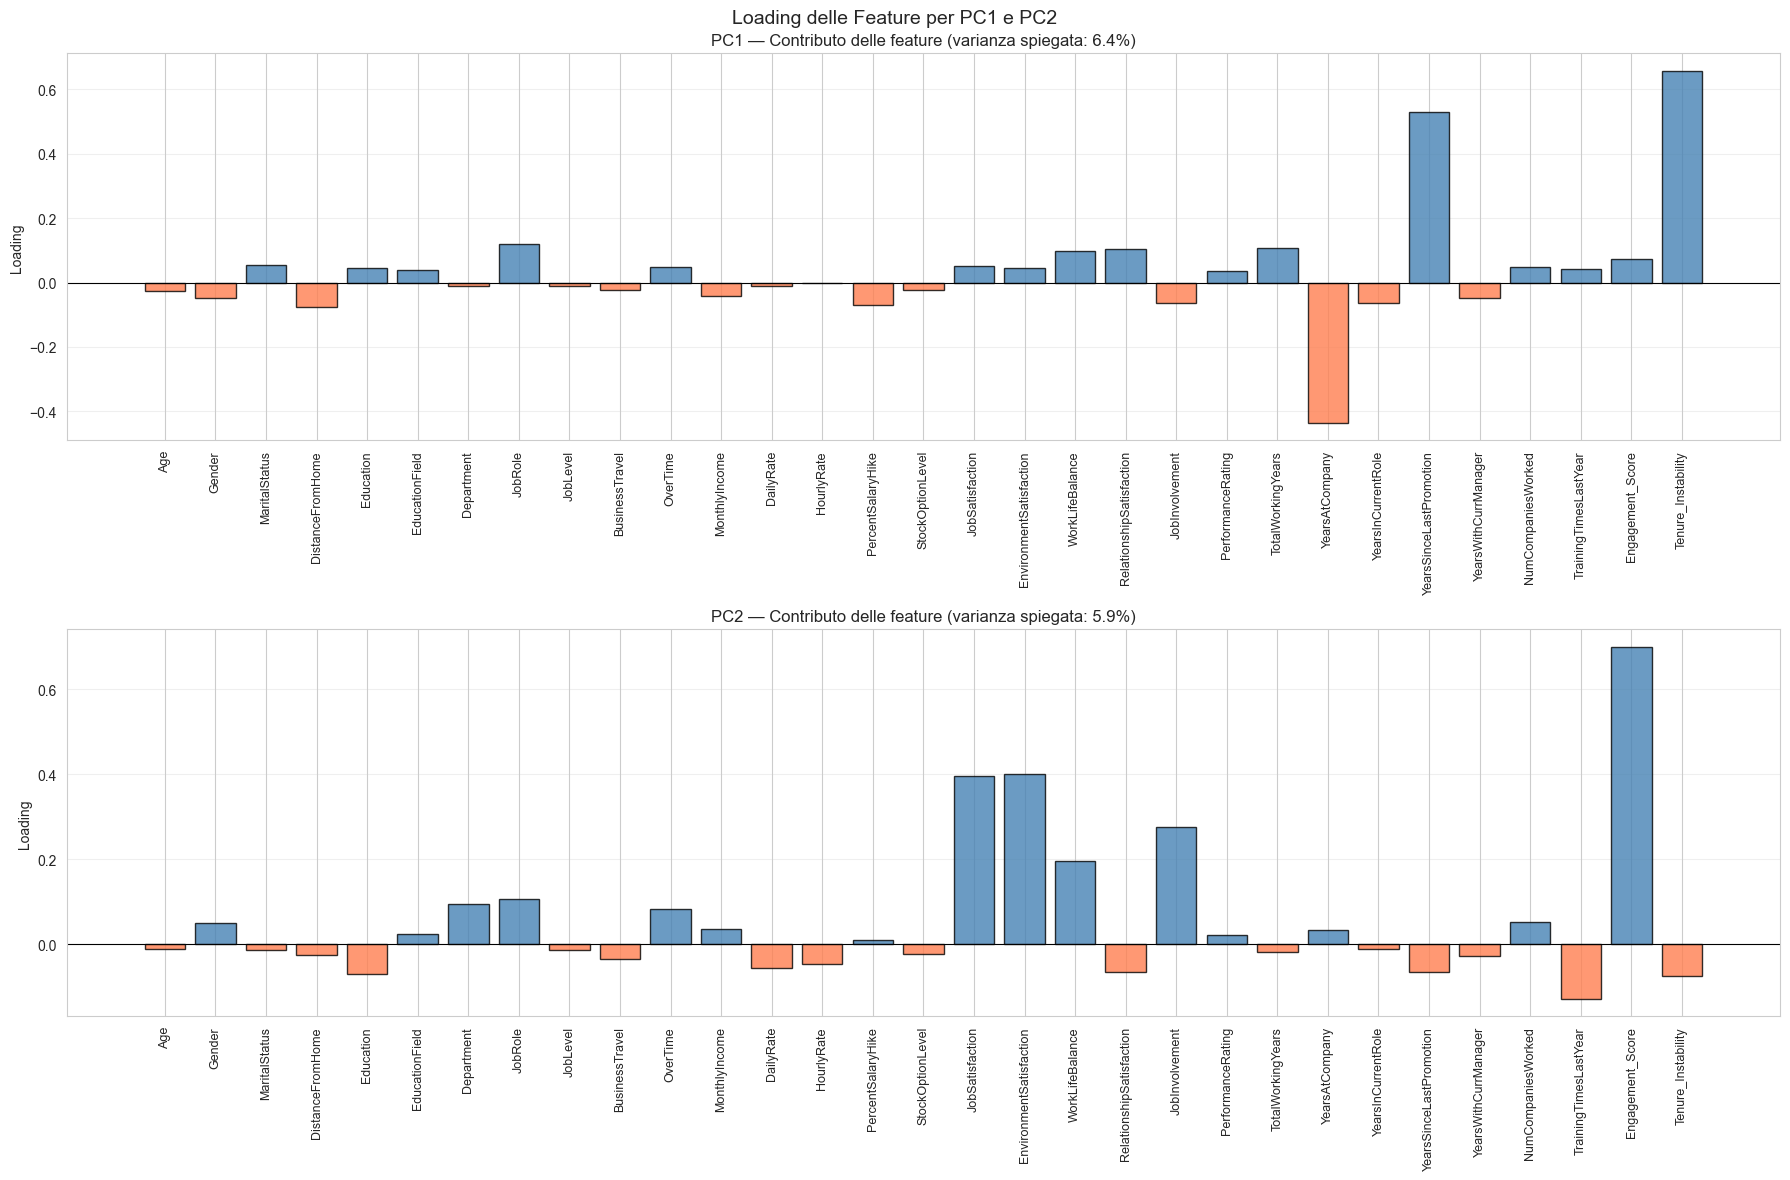

In [57]:
fig, axes = plt.subplots(2, 1, figsize=(18, 12))

for pc_idx, ax in enumerate(axes):
    loadings = pca.components_[pc_idx, :]
    colors_bar = ['steelblue' if v >= 0 else 'coral' for v in loadings]
    ax.bar(np.arange(n_feat), loadings, color=colors_bar, edgecolor='black', alpha=0.8)
    ax.set_xticks(np.arange(n_feat))
    ax.set_xticklabels(feature_names, rotation=90, fontsize=9)
    ax.axhline(0, color='black', linewidth=0.8)
    ax.set_title(f'PC{pc_idx + 1} — Contributo delle feature'
                 f' (varianza spiegata: {pca.explained_variance_ratio_[pc_idx]*100:.1f}%)')
    ax.set_ylabel('Loading')
    ax.grid(axis='y', alpha=0.3)

plt.suptitle('Loading delle Feature per PC1 e PC2', fontsize=14)
plt.tight_layout()
plt.show()

In [58]:
for pc_idx in range(min(3, pca.n_components_)):
    loadings = pd.Series(pca.components_[pc_idx], index=feature_names)
    top_pos  = loadings.nlargest(5)
    top_neg  = loadings.nsmallest(5)
    print(f'=== PC{pc_idx+1} ===')
    print(f'  Top contributi positivi (spingono verso +PC{pc_idx+1}):')
    for feat, val in top_pos.items():
        print(f'    {feat:30s}: {val:.4f}')
    print(f'  Top contributi negativi (spingono verso -PC{pc_idx+1}):')
    for feat, val in top_neg.items():
        print(f'    {feat:30s}: {val:.4f}')
    print()

=== PC1 ===
  Top contributi positivi (spingono verso +PC1):
    Tenure_Instability            : 0.6572
    YearsSinceLastPromotion       : 0.5293
    JobRole                       : 0.1192
    TotalWorkingYears             : 0.1077
    RelationshipSatisfaction      : 0.1052
  Top contributi negativi (spingono verso -PC1):
    YearsAtCompany                : -0.4355
    DistanceFromHome              : -0.0763
    PercentSalaryHike             : -0.0683
    YearsInCurrentRole            : -0.0644
    JobInvolvement                : -0.0631

=== PC2 ===
  Top contributi positivi (spingono verso +PC2):
    Engagement_Score              : 0.6990
    EnvironmentSatisfaction       : 0.3996
    JobSatisfaction               : 0.3958
    JobInvolvement                : 0.2751
    WorkLifeBalance               : 0.1963
  Top contributi negativi (spingono verso -PC2):
    TrainingTimesLastYear         : -0.1279
    Tenure_Instability            : -0.0749
    Education                     : -0.06

## 7. Riepilogo Finale

### Dataset prodotto

| Step | Azione | Risultato |
|---|---|---|
| Rimozione rumore | `Random_Survey_Noise`, `PerformanceRating` (se quasi costante) | Feature ridotte |
| Imputation | `Engagement_Score` con media train | 0 missing |
| Outlier capping | IQR su variabili ratio | Dati robusti |
| Encoding | LabelEncoder su 7 variabili object | Tutto numerico |
| PCA (90%) | StandardScaler + PCA | Spazio ridotto |

### Interpretazione PCA
- **PC1** cattura principalmente la *seniority* del dipendente (TotalWorkingYears, YearsAtCompany, Age, MonthlyIncome correlati positivamente)
- **PC2** cattura la *mobilità/instabilità lavorativa* (NumCompaniesWorked, Tenure_Instability vs variabili di stabilità)
- Le classi (Rimasto/Uscito) non sono linearmente separabili nello spazio PCA → motivazione per algoritmi non lineari

Il dataset preprocessato (`X_train`, `y_train`, `X_test`, `y_test`) è pronto per la fase di classificazione.